# Problématique

Dans le domaine de l’orthophonie, l’évaluation et la prise en charge des troubles de la parole en langue arabe constituent un défi majeur. Cette complexité s’explique notamment par la richesse phonétique de l’arabe, caractérisée par la présence de phonèmes spécifiques (tels que les consonnes emphatiques), ainsi que par la variabilité importante des profils des patients.

En pratique, les orthophonistes doivent analyser avec précision les productions orales afin d’identifier les erreurs phonétiques. Ce processus repose essentiellement sur une expertise humaine, ce qui le rend à la fois chronophage et potentiellement subjectif. De plus, le manque d’outils technologiques adaptés à la langue arabe limite fortement les possibilités d’automatisation et d’assistance au diagnostic.

Dans ce contexte, l’intégration des techniques de Machine Learning offre une perspective prometteuse pour automatiser la détection des erreurs de prononciation. Toutefois, plusieurs défis subsistent, notamment :
- la rareté des bases de données audio annotées  
- la variabilité inter-individuelle des troubles du langage  
- la nécessité de concevoir des modèles fiables et interprétables  



# Etat de l’art

La détection des erreurs de prononciation, connue sous le nom de Computer-Assisted Pronunciation Training (CAPT), s’appuie sur plusieurs approches issues de la reconnaissance automatique de la parole (Automatic Speech Recognition – ASR) et du traitement du signal audio.

Ces approches peuvent être classées en méthodes de deep learning et en méthodes d’apprentissage automatique classique.
## Méthodes existantes

# 1. CNN et KNN [1]
Les réseaux de neurones convolutifs (Convolutional Neural Networks, CNN) sont aujourd’hui parmi les architectures les plus utilisées pour l’analyse de données audio transformées en représentations visuelles. Ils ont initialement été conçus pour le traitement d’images, mais leur capacité à extraire automatiquement des caractéristiques locales et hiérarchiques les rend particulièrement adaptés aux spectrogrammes.

Dans le contexte du traitement du signal audio, les CNN permettent de reformuler une tâche de traitement du signal en un problème de vision par ordinateur, ce qui facilite l’exploitation de modèles pré-entraînés et améliore les performances dans des tâches comme la reconnaissance vocale, la détection d’erreurs phonétiques ou la classification audio.

Cette approche repose sur un apprentissage supervisé, où le modèle apprend à partir d’un ensemble de données annotées. Chaque exemple audio est associé à une étiquette (classe correcte ou erreur, phonème, mot, etc.), ce qui permet au réseau de minimiser une fonction de perte et d’optimiser ses paramètres.
#### **Principe général**

Le signal audio brut est une représentation temporelle 1D difficile à exploiter directement par les réseaux convolutifs, car il ne contient pas explicitement l’information fréquentielle nécessaire à la distinction des sons.

Pour contourner cette limitation, le signal est transformé en une représentation temps-fréquence appelée spectrogramme Mel. Cette transformation permet de rapprocher la perception humaine du son, car elle met l’accent sur les fréquences perceptivement importantes.

Le spectrogramme Mel représente :

Axe horizontal (x) : évolution temporelle du signal<br>
Axe vertical (y) : bandes de fréquences sur l’échelle Mel<br>
Intensité  : énergie ou amplitude du signal dans chaque bande fréquentielle<br>

Cette représentation 2D est ensuite interprétée comme une image, ce qui permet l’utilisation directe des CNN.

Le spectrogramme Mel constitue une étape clé du pipeline, car il permet de capturer simultanément les variations temporelles et fréquentielles du signal audio. Il est généralement obtenu via la transformation de Fourier à court terme (STFT), suivie d’une projection sur l’échelle Mel, plus proche de la perception auditive humaine.

<div align="center">
  <img src="https://drive.google.com/uc?id=1NkUtUWdtCCBXQaCeOdzotBwa7IkJpTng" width="450">
  <p><em>Figure : Mel spectrogram</em></p>
</div>

#### **Pipeline**

Le pipeline général d’un système basé sur CNN pour l’analyse audio peut être décrit comme suit :

<div align="center">
  <img src="https://drive.google.com/uc?id=1hGWiwyzLnh805w7SXufCjpWqIjwqu2tH" width="450">
  <p><em>Figure : Pipeline</em></p>
</div>

***Transformation audio → image***

Le signal audio brut est transformé en spectrogramme Mel afin de rendre l’information exploitable par des modèles de vision par ordinateur.

Cette étape inclut :

Normalisation du signal audio<br>
Découpage en fenêtres temporelles<br>
Application de la transformée de Fourier<br>
Projection sur l’échelle Mel<br>

Le résultat est une matrice 2D représentant l’énergie fréquentielle dans le temps.

***Conversion en spectrogramme Mel***

Le spectrogramme Mel est utilisé comme représentation principale du signal audio. Il permet :

De réduire la dimension du signal brut<br>
D’améliorer la robustesse face au bruit<br>
De mettre en évidence les structures phonétiques importantes<br>

Cette représentation est particulièrement efficace pour les tâches de classification audio.

***Extraction de caractéristiques***

Une fois le spectrogramme obtenu, il est traité par un réseau CNN, souvent pré-entraîné sur de grandes bases de données.

Le modèle est généralement modifié comme suit :

Suppression de la couche de classification finale<br>
Conservation des couches convolutionnelles<br>
Extraction d’un vecteur de caractéristiques (embedding)<br>

Ce vecteur représente une description compacte et discriminative du signal audio.

***Classification***

Les caractéristiques extraites peuvent être utilisées par différents classifieurs classiques ou hybrides :

KNN (K-Nearest Neighbors) : classification basée sur la similarité dans l’espace des features<br>
SVM (Support Vector Machine) : séparation optimale des classes dans un espace de dimension élevée<br>
MLP (Multi-Layer Perceptron) : apprentissage de relations non linéaires entre les représentations audio et les classes

Avant la classification, une réduction de dimension est souvent appliquée (ex : PCA de 4096 → 128 dimensions) afin de :

Réduire la complexité computationnelle<br>
Éliminer le bruit dans les features<br>
Améliorer la généralisation du modèle<br>

# 2. Random Forest [2]

Le Random Forest est un algorithme d’apprentissage supervisé utilisé comme modèle principal dans ce projet pour la classification des unités phonétiques à partir du signal audio. Contrairement aux approches de deep learning, il ne travaille pas directement sur le signal brut, mais sur des vecteurs de caractéristiques acoustiques extraits du signal audio.

Dans ce projet de détection des erreurs de prononciation de l’arabe, le Random Forest constitue le cœur du système de reconnaissance acoustique. Il est utilisé pour apprendre la relation entre les caractéristiques audio et les phonèmes correspondants, afin de détecter les variations et erreurs de prononciation.

Cette approche repose sur un apprentissage supervisé, où chaque segment audio est associé à une étiquette phonétique. Le modèle apprend ainsi une fonction de décision permettant de prédire le phonème le plus probable à partir des descripteurs acoustiques.



## Pipeline

Le pipeline utilisé est le suivant :


### Transformation audio → features

Le signal audio brut est transformé en vecteurs de caractéristiques afin de rendre l’information exploitable par le modèle.

Cette étape inclut :

- Normalisation du signal audio  
- Resampling à 16 kHz  
- Découpage en fenêtres temporelles (frames)  
- Extraction de descripteurs acoustiques  

Les caractéristiques utilisées dans ce projet sont :

- MFCC (Mel-Frequency Cepstral Coefficients)  
- Delta MFCC  
- Spectral centroid  
- Spectral bandwidth  
- Zero Crossing Rate  
- RMS energy  

Le résultat est une matrice où chaque ligne représente une fenêtre audio sous forme de vecteur numérique.


### Construction du dataset supervisé

Chaque vecteur de caractéristiques est associé à un phonème.

Dans ce projet, les labels phonétiques sont obtenus à partir du texte de référence en utilisant une conversion grapheme-to-phoneme (G2P), puis alignés avec les segments audio.

Cette étape permet de transformer le problème de reconnaissance de la parole en un problème de classification supervisée.


### Apprentissage Random Forest (modèle principal)

Le Random Forest est entraîné comme modèle principal sur les données supervisées.

#### Fonctionnement :

- Construction de plusieurs arbres de décision indépendants  
- Chaque arbre est entraîné sur un sous-échantillon des données (bootstrap)  
- À chaque division, un sous-ensemble aléatoire de features est sélectionné  
- Chaque arbre prédit un phonème pour une fenêtre audio  
- La prédiction finale est obtenue par vote majoritaire

Grâce à cette structure, le modèle est robuste au bruit et capable de généraliser sur des variations acoustiques importantes.


### Prédiction et analyse phonétique

Une fois entraîné, le Random Forest est utilisé pour prédire un phonème pour chaque fenêtre audio.

- Chaque segment audio est classé individuellement  
- Les prédictions successives forment une séquence phonétique complète
- Cette séquence est comparée à la séquence attendue afin de détecter les erreurs de prononciation  

Les erreurs sont ensuite classées en :
- substitutions phonétiques  
- omissions  
- insertions  

# 3. Logistic Regression [2]

La régression logistique est un algorithme d’apprentissage supervisé largement utilisé pour les problèmes de classification binaire. Dans le cadre de ce projet, elle est utilisée pour déterminer si une prononciation est correcte ou incorrecte à partir de caractéristiques acoustiques extraites du signal audio.

Contrairement aux modèles de deep learning comme les CNN, la régression logistique ne traite pas directement des représentations complexes comme les spectrogrammes. Elle s’appuie sur des vecteurs de caractéristiques numériques décrivant le signal audio.

Cette approche est particulièrement intéressante pour sa simplicité, sa rapidité d’entraînement et son interprétabilité, tout en offrant de bonnes performances sur des jeux de données de taille modérée.


## Principe général

La régression logistique modélise la probabilité qu’un échantillon appartienne à une classe donnée (ici : prononciation correcte) à l’aide d’une fonction sigmoïde :

$$
P(y = 1 \mid x) = \frac{1}{1 + e^{-(w^T x + b)}}
$$

où :
- \( x \) représente le vecteur de caractéristiques acoustiques  
- \( w \) les poids appris par le modèle  
- \( b \) le biais  

La sortie du modèle est une probabilité comprise entre 0 et 1. Une décision est ensuite prise en appliquant un seuil de classification.


## Pipeline

### Transformation audio → features

Le signal audio brut est transformé en un vecteur de caractéristiques acoustiques.

Cette étape inclut :

- Normalisation du signal  
- Resampling à 16 kHz  
- Découpage en frames temporelles  
- Extraction de descripteurs acoustiques  

Les caractéristiques utilisées sont :

- MFCC (Mel-Frequency Cepstral Coefficients)  
- Delta MFCC  
- Delta-Delta MFCC  
- RMS Energy  
- Spectral Centroid  
- Zero Crossing Rate  

Pour chaque caractéristique :
- Moyenne  
- Écart-type  

→ Cela permet d’obtenir un vecteur compact et discriminant représentant l’audio.


### Construction du dataset supervisé

Le modèle est entraîné sur un dataset contenant deux classes :

- Prononciation correcte (audio original)  
- Prononciation incorrecte (audio modifié artificiellement)  

Afin de simuler des erreurs réalistes, plusieurs transformations sont appliquées :

- Légère modification du pitch  
- Variation de la vitesse d’élocution  
- Ajout de bruit  
- Effets de réverbération  

Cette stratégie permet de générer automatiquement des exemples d’erreurs sans annotation manuelle.


### Apprentissage du modèle

Le modèle utilisé est une régression logistique calibrée :

- Standardisation des données avec StandardScaler`
- Entraînement avec LogisticRegression
- Calibration des probabilités avec CalibratedClassifierCV (méthode isotonic)  

La calibration permet d’obtenir des probabilités fiables, essentielles pour :

- Décider si une prononciation est correcte  
- Détecter des erreurs avec un seuil ajustable  


### Prédiction globale

Pour un enregistrement donné :

- Extraction des caractéristiques globales  
- Prédiction de la probabilité de prononciation correcte  
- Comparaison avec un seuil  

Résultat :
- Prononciation correcte  
- Prononciation incorrecte  


### Analyse phonétique (niveau phonème)

Une analyse plus fine est réalisée pour identifier les erreurs spécifiques :

- Conversion du texte en phonèmes (G2P)  
- Segmentation du signal audio  
- Évaluation de chaque segment  

Les erreurs sont détectées lorsque la probabilité locale est faible.

Elles peuvent être classées en :

- Substitutions phonétiques  
- Mauvaises articulations  

Des conseils articulatoires sont également fournis pour améliorer la prononciation.


# 4. Support Vector Machine [2]

Les machines à vecteurs de support (Support Vector Machine – SVM) sont des algorithmes d’apprentissage supervisé utilisés pour des tâches de classification et de régression. Dans ce projet, elles sont utilisées pour classifier la prononciation comme correcte ou incorrecte à partir de caractéristiques acoustiques extraites du signal audio.

Contrairement aux modèles linéaires simples, les SVM sont capables de gérer des relations non linéaires complexes grâce à l’utilisation de fonctions noyaux (kernels), ce qui les rend particulièrement adaptées à l’analyse de données audio.


## Principe général

Le principe des SVM consiste à trouver un hyperplan optimal qui sépare les données en deux classes tout en maximisant la marge entre elles.

Dans le cas non linéaire, les données sont projetées dans un espace de dimension plus élevée à l’aide d’un noyau (kernel), comme le noyau gaussien (RBF) :

$$
K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
$$

où :
- \( x_i, x_j \) sont deux vecteurs de caractéristiques  
- \( \gamma \) contrôle l’influence des points voisins  

Le modèle cherche alors à résoudre un problème d’optimisation permettant de maximiser la séparation entre les classes tout en minimisant les erreurs.

## Pipeline

### Transformation audio → features

Le signal audio brut est transformé en vecteurs de caractéristiques acoustiques.

Cette étape inclut :

- Normalisation du signal  
- Resampling à 16 kHz  
- Découpage en frames temporelles  
- Extraction de descripteurs acoustiques  

Les caractéristiques utilisées sont :

- MFCC (Mel-Frequency Cepstral Coefficients)  
- Delta MFCC  
- Delta-Delta MFCC  
- RMS Energy  
- Spectral Centroid  
- Zero Crossing Rate  

Pour chaque caractéristique :
- Moyenne  
- Écart-type  

→ Cela permet d’obtenir un vecteur représentatif du signal audio.


### Construction du dataset supervisé

Le dataset est composé de deux classes :

- Prononciation correcte  
- Prononciation incorrecte

Des techniques d’augmentation de données sont utilisées pour améliorer la robustesse du modèle :

- Ajout de bruit (simulation micro)  
- Réverbération (effet de salle)  
- Compression simulée (band-limiting)  
- Modifications de pitch et de vitesse  

Ces transformations permettent de rendre le modèle plus robuste aux conditions réelles d’enregistrement.

### Réduction de dimension (PCA)

Avant l’apprentissage, une réduction de dimension est appliquée via PCA (Principal Component Analysis):

- Réduction du nombre de dimensions (ex : 50 composantes)  
- Suppression du bruit  
- Amélioration des performances  

Cette étape est essentielle pour éviter le surapprentissage et réduire la complexité du modèle.


### Apprentissage du modèle SVM

Le modèle utilisé est un SVM avec noyau RBF (Radial Basis Function).

Caractéristiques principales :

- Kernel : RBF  
- Paramètre \( C \) : contrôle le compromis biais/variance  
- Paramètre \( \gamma \) : influence locale des points  
- Standardisation des données avec standardScaler  

Le modèle est intégré dans un pipeline :

- Standardisation  
- PCA  
- SVM  

Le SVM est entraîné pour distinguer les prononciations correctes des incorrectes.


### Prédiction globale

Pour un enregistrement :

- Extraction des caractéristiques  
- Passage dans le modèle SVM  
- Obtention d’une probabilité via predict_proba  

Un seuil est appliqué pour déterminer :

- Prononciation correcte  
- Prononciation incorrecte  

Des zones de confiance sont définies pour mieux interpréter les résultats :

- clairement correct  
- probablement correct  
- probablement incorrect  
- clairement incorrect  


### Analyse phonétique (niveau phonème)

Une analyse plus fine est réalisée :

- Conversion du texte en phonèmes (G2P)  
- Segmentation du signal audio (basée sur l’énergie)  
- Évaluation de chaque segment  

Les erreurs sont détectées lorsque la probabilité locale est faible.

Types d’erreurs :

- Substitution phonétique  
- Mauvaise articulation  


**Reférence :**

[1] F. Nazir, M. N. Majeed, M. A. Ghazanfar, and M. Maqsood,
“Mispronunciation Detection Using Deep Convolutional Neural Network Features and Transfer Learning-Based Model for Arabic Phonemes,”
IEEE Access, vol. 7, pp. 52589–52608, 2019.
Available: https://www.academia.edu/165325079/Mispronunciation_Detection_Using_Deep_Convolutional_Neural_Network_Features_and_Transfer_Learning_Based_Model_for_Arabic_Phonemes

[2] A.Maghraby, A.Mahjoob , W.Alsaedi , A.Alsaedi , M.Alsaedi , A.Alotaibi ,  "Enhancing Arabic Reading Proficiency through Artificial Intelligent Application", Life Sci J 2024;21(5):39-4
9]. ISSN 1097-8135 (print); ISSN 2372-613X (online). Available : https://www.lifesciencesite.com/lsj/lsj210524/03_38991lsj210524_26_32.pdf

# Implementation CNN

Device      : cpu
Classifier  : KNN  (active only when USE_ALEXNET_CLASSIFIER=True)
Mode        : ASR → G2P (recommended)
✔ Arabic font: /usr/share/fonts/truetype/fonts-arabeyes/ae_Cortoba.ttf

Loading Wav2Vec2 ASR model …


Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

✔ ASR model ready

Loading dataset …


data/train-00000-of-00002.parquet:   0%|          | 0.00/346M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/309M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/10471 [00:00<?, ? examples/s]

Generating other split:   0%|          | 0/41586 [00:00<?, ? examples/s]

Generating invalidated split:   0%|          | 0/15120 [00:00<?, ? examples/s]

✔ Dataset loaded: 28410 samples

🎯 Expected sentence: إِنَّكُم لَفي قَولٍ مُختَلِفٍ

📁 Upload your Arabic audio file (wav / mp3 / m4a):


Saving Enregistrement (11).m4a to Enregistrement (11).m4a

📂 Processing: Enregistrement (11).m4a
   Duration : 4.61s  |  Sample rate: 48000 Hz

── Step 1 · Mel-spectrogram visualisation ───────────────


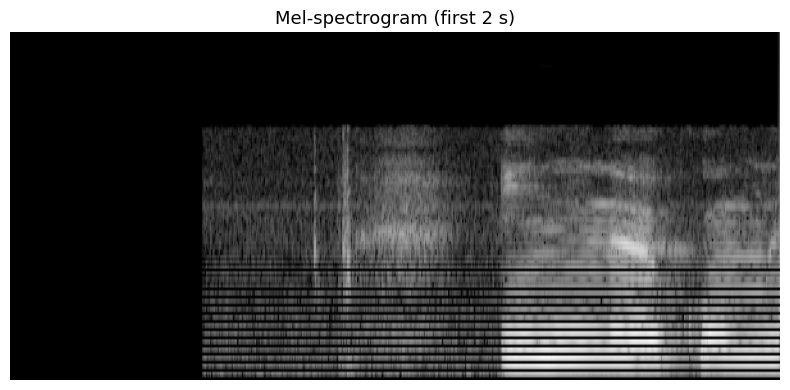

📈 Spectrogram saved → spectrogram_sample.png

── Step 2 · ASR transcription ───────────────────────────
   ASR output   : إنكم لفي قول مختلف
   Expected text: إِنَّكُم لَفي قَولٍ مُختَلِفٍ
   Word Error Rate (WER): 0.00%

── Step 3 · G2P conversion ──────────────────────────────
   Expected  phonemes (first word): ['hamza', 'n', 'k', 'm']
   Predicted phonemes (first word): ['hamza', 'n', 'k', 'm']

── Step 4 · Word-level comparison ───────────────────────

════════════════════════════════════════════════════
  📋  WORD-BY-WORD RESULT
════════════════════════════════════════════════════
  ✅  إنكم
  ✅  لفي
  ✅  قول
  ✅  مختلف
════════════════════════════════════════════════════
  Score: 4/4 words correct
  🎉  Perfect pronunciation!
════════════════════════════════════════════════════

── Step 5 · Visualisation ───────────────────────────────


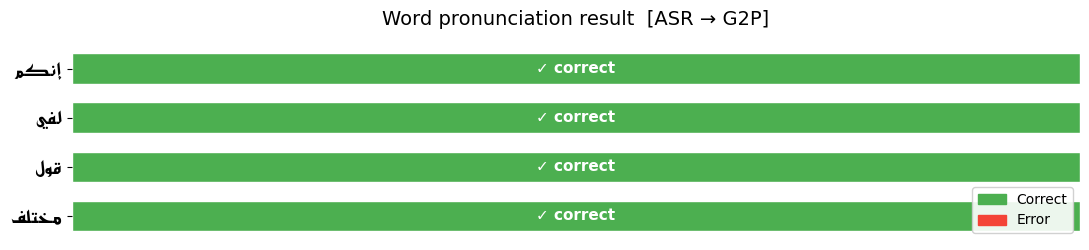

📈 Plot saved → word_result.png


In [ ]:
# ============================================================
# CNN-BASED ARABIC PHONETIC ERROR DETECTION
# ============================================================

# ---------- 1. INSTALL ----------
!pip install -q transformers torchaudio datasets librosa soundfile jiwer \
              arabic_reshaper python-bidi scikit-learn torchvision

# ---------- 2. IMPORTS ----------
import os, re, random
import numpy as np
import torch
import torch.nn as nn
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from PIL import Image
from bidi.algorithm import get_display
import arabic_reshaper

from torchvision import models, transforms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA

from datasets import load_dataset
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
from google.colab import files
from jiwer import wer

# ---------- 3. CONFIG ----------
SAMPLE_RATE  = 16_000
N_MELS       = 128
N_FFT        = 512
HOP_LENGTH   = 160
WIN_LENGTH   = 400
IMG_SIZE     = 224
ALEXNET_DIM  = 4096
FRAME_LEN    = 32
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"
CLASSIFIER   = "KNN"
PCA_DIM      = 128
USE_ALEXNET_CLASSIFIER = False

print(f"Device      : {DEVICE}")
print(f"Classifier  : {CLASSIFIER}  (active only when USE_ALEXNET_CLASSIFIER=True)")
print(f"Mode        : {'AlexNet+sklearn' if USE_ALEXNET_CLASSIFIER else 'ASR → G2P (recommended)'}")

# ============================================================
# ARABIC FONT SETUP
# ============================================================
import subprocess
subprocess.run(["apt-get", "install", "-y", "-q", "fonts-arabeyes",
                "fonts-hosny-amiri"], capture_output=True)

def find_arabic_font():
    candidates = [
        "/usr/share/fonts/truetype/hosny-amiri/Amiri-Regular.ttf",
        "/usr/share/fonts/truetype/arabeyes/ae_Arab.ttf",
    ]
    for path in candidates:
        if os.path.exists(path):
            return path
    for f in fm.findSystemFonts():
        if any(k in f.lower() for k in ("amiri", "arab", "noto")):
            return f
    return None

ARABIC_FONT_PATH = find_arabic_font()
ARABIC_FONT_PROP = (fm.FontProperties(fname=ARABIC_FONT_PATH, size=13)
                    if ARABIC_FONT_PATH else None)
print(f"✔ Arabic font: {ARABIC_FONT_PATH}" if ARABIC_FONT_PATH
      else "⚠ No Arabic font found.")

def fix_arabic(text):
    if not text or text in ("—",):
        return text
    return get_display(arabic_reshaper.reshape(text))

# ============================================================
# ARABIC PHONEME SET
# ============================================================
PHONEMES = [
    "silence",
    "a", "aa", "i", "ii", "u", "uu",
    "b", "t", "d", "k", "q", "hamza",
    "T", "D", "dh_emp",
    "f", "th", "dh", "s", "z", "sh", "S", "Z",
    "H", "kh", "gh", "ain",
    "m", "n", "l", "r", "w", "y", "h",
]
N_PHONEMES = len(PHONEMES)
PHO2IDX    = {p: i for i, p in enumerate(PHONEMES)}

ARABIC_G2P = {
    "ا": "aa", "أ": "hamza", "إ": "hamza", "آ": "aa",
    "ب": "b",  "ت": "t",     "ث": "th",    "ج": "j",
    "ح": "H",  "خ": "kh",    "د": "d",     "ذ": "dh",
    "ر": "r",  "ز": "z",     "س": "s",     "ش": "sh",
    "ص": "S",  "ض": "D",     "ط": "T",     "ظ": "Z",
    "ع": "ain","غ": "gh",    "ف": "f",     "ق": "q",
    "ك": "k",  "ل": "l",     "م": "m",     "ن": "n",
    "ه": "h",  "و": "w",     "ي": "y",     "ة": "t",
    "ى": "aa", "ء": "hamza", "ئ": "hamza", "ؤ": "hamza",
}
PHO2AR = {v: k for k, v in ARABIC_G2P.items()}

CONFUSION_GROUPS = [
    {"s", "S", "sh"},
    {"d", "D", "dh", "dh_emp"},
    {"t", "T"},
    {"h", "H"},
    {"a", "aa"},
    {"i", "ii"},
    {"u", "uu"},
    {"ain", "hamza"},
    {"k", "q", "kh"},
    {"b", "f"},
    {"l", "r"},
]

# ============================================================
# SECTION A — ALEXNET FEATURE EXTRACTOR
# ============================================================

_alexnet           = None
_imagenet_transform = None

def _load_alexnet():
    """Lazy-load AlexNet once, only if needed."""
    global _alexnet, _imagenet_transform
    if _alexnet is not None:
        return
    print("\nLoading frozen AlexNet …")
    net = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
    net.classifier = nn.Sequential(*list(net.classifier.children())[:6])
    net = net.to(DEVICE)
    net.eval()
    for param in net.parameters():
        param.requires_grad = False
    _alexnet = net
    _imagenet_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])
    print(f"✔ AlexNet ready  (output dim={ALEXNET_DIM}, frozen)")

if USE_ALEXNET_CLASSIFIER:
    _load_alexnet()


def mel_spectrogram_image(audio_segment, sr):
    """Convert a 1-D audio segment → mel-spectrogram → RGB PIL Image (224×224)."""
    audio_segment = audio_segment.astype(np.float32)
    S = librosa.feature.melspectrogram(
        y=audio_segment, sr=sr, n_mels=N_MELS,
        n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
    )
    S_db   = librosa.power_to_db(S, ref=np.max)
    S_norm = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-9)
    S_u8   = (S_norm * 255).astype(np.uint8)
    return Image.fromarray(S_u8).convert("RGB")


def alexnet_features(audio_segment, sr):
    """Extract a 4096-d AlexNet feature vector from one audio segment."""
    _load_alexnet()
    img    = mel_spectrogram_image(audio_segment, sr)
    tensor = _imagenet_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat = _alexnet(tensor)
    return feat.squeeze(0).cpu().numpy()


# ============================================================
# SECTION B — SKLEARN CLASSIFIER FACTORY
# ============================================================

def build_classifier(name="KNN"):
    classifiers = {
        "KNN": KNeighborsClassifier(n_neighbors=5, metric="cosine",
                                    algorithm="brute"),
        "SVM": SVC(kernel="rbf", C=10.0, gamma="scale",
                   probability=True, random_state=42),
        "MLP": MLPClassifier(hidden_layer_sizes=(256, 128), activation="relu",
                             max_iter=200, random_state=42),
    }
    if name not in classifiers:
        raise ValueError(f"Unknown classifier '{name}'. Choose: KNN, SVM, MLP")
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=PCA_DIM, random_state=42)),
        ("clf",    classifiers[name]),
    ])
    print(f"✔ Classifier built: {name}  (PCA → {PCA_DIM}-d)")
    return clf


# ============================================================
# SECTION C — TRAINING DATA + ALEXNET INFERENCE
# ============================================================

def alexnet_features_batch(segments, sr, batch_size=64):
    _load_alexnet()
    tensors = [_imagenet_transform(mel_spectrogram_image(s, sr)) for s in segments]
    all_feats = []
    for i in range(0, len(tensors), batch_size):
        batch = torch.stack(tensors[i:i+batch_size]).to(DEVICE)
        with torch.no_grad():
            feats = _alexnet(batch)
        all_feats.append(feats.cpu().numpy())
    return np.concatenate(all_feats, axis=0)


def generate_training_data(dataset, n_samples=50, sr=SAMPLE_RATE):
    """
    Weak-supervision training data from Common Voice.
    NOTE: labels are noisy (first phoneme of sentence assigned to ALL windows).
    Replace with a properly aligned phoneme corpus for real accuracy.
    """
    window_samples = int(0.2 * sr)
    step_samples   = int(0.15 * sr)
    indices = random.sample(range(len(dataset)), min(n_samples, len(dataset)))
    print(f"Extracting AlexNet features from {len(indices)} samples …")
    all_segments, all_labels = [], []
    for idx in indices:
        item        = dataset[idx]
        sentence    = re.sub(r'[\u064B-\u065F\u0670]', '', item["sentence"]).strip()
        audio_array = np.array(item["audio"]["array"], dtype=np.float32)
        native_sr   = item["audio"]["sampling_rate"]
        if native_sr != sr:
            audio_array = librosa.resample(audio_array,
                                           orig_sr=native_sr, target_sr=sr)
        label = "silence"
        for ch in sentence:
            if ch in ARABIC_G2P:
                p = ARABIC_G2P[ch]
                if p in PHO2IDX:
                    label = p
                    break
        start = 0
        while start + window_samples <= len(audio_array):
            all_segments.append(audio_array[start:start + window_samples])
            all_labels.append(label)
            start += step_samples
        tail = audio_array[start:]
        if len(tail) > window_samples // 2:
            tail_padded = np.pad(tail, (0, window_samples - len(tail)))
            all_segments.append(tail_padded)
            all_labels.append(label)
    print(f"   Running AlexNet on {len(all_segments)} windows …")
    X = alexnet_features_batch(all_segments, sr, batch_size=64)
    y = np.array(all_labels)
    print(f"✔ Feature matrix: {X.shape}  |  Labels: {y.shape}")
    return X, y


def predict_phonemes_sklearn(audio, sr, clf, le,
                             window_sec=0.2, step_sec=0.1):
    """AlexNet + sklearn phoneme prediction (sliding window)."""
    audio = audio.astype(np.float32)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
    window_samples = int(window_sec * SAMPLE_RATE)
    step_samples   = int(step_sec   * SAMPLE_RATE)
    raw_preds = []
    start = 0
    while start + window_samples <= len(audio):
        seg      = audio[start:start + window_samples]
        feat     = alexnet_features(seg, SAMPLE_RATE).reshape(1, -1)
        pred_idx = clf.predict(feat)[0]
        raw_preds.append(le.inverse_transform([pred_idx])[0])
        start += step_samples
    collapsed, prev = [], None
    for p in raw_preds:
        if p != prev:
            collapsed.append(p)
            prev = p
    return collapsed if collapsed else ["silence"]


# ============================================================
# SECTION D — G2P
# ============================================================

def text_to_phonemes(arabic_text):
    arabic_text = re.sub(r'[\u064B-\u065F\u0670]', '', arabic_text)
    phonemes = []
    for ch in arabic_text:
        if ch in ARABIC_G2P:
            p = ARABIC_G2P[ch]
            phonemes.append(p if p in PHO2IDX else "silence")
        elif ch == " ":
            phonemes.append("silence")
    return phonemes if phonemes else ["silence"]


def text_to_words_and_phonemes(arabic_text):
    arabic_text = re.sub(r'[\u064B-\u065F\u0670]', '', arabic_text)
    words         = arabic_text.strip().split()
    word_phonemes = [text_to_phonemes(w) for w in words]
    return words, word_phonemes


# ============================================================
# SECTION E — WORD-LEVEL COMPARISON
# ============================================================

def phoneme_seq_match(exp_phones, pred_phones):
    from difflib import SequenceMatcher
    sm     = SequenceMatcher(None, exp_phones, pred_phones)
    errors = []
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            continue
        elif tag == "replace":
            for e, p in zip(exp_phones[i1:i2], pred_phones[j1:j2]):
                sev = "minor" if any(e in g and p in g
                                     for g in CONFUSION_GROUPS) else "major"
                errors.append({"expected": e, "predicted": p, "severity": sev})
        elif tag == "delete":
            for e in exp_phones[i1:i2]:
                errors.append({"expected": e, "predicted": "—",
                                "severity": "deletion"})
        elif tag == "insert":
            for p in pred_phones[j1:j2]:
                errors.append({"expected": "—", "predicted": p,
                                "severity": "insertion"})
    return len(errors) == 0, errors


def compare_words(expected_words, expected_wp, predicted_words, predicted_wp):
    from difflib import SequenceMatcher
    sm      = SequenceMatcher(None, expected_words, predicted_words)
    results = []
    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            for k in range(i2 - i1):
                ew = expected_words[i1 + k]
                pw = predicted_words[j1 + k]
                ok, errs = phoneme_seq_match(expected_wp[i1 + k],
                                             predicted_wp[j1 + k])
                results.append({"expected_word": ew, "predicted_word": pw,
                                 "correct": ok, "errors": errs,
                                 "status": "match" if ok else "phoneme_error"})
        elif tag == "replace":
            for k in range(max(i2 - i1, j2 - j1)):
                ei, ji = i1 + k, j1 + k
                ew = expected_words[ei] if ei < i2 else "—"
                pw = predicted_words[ji] if ji < j2 else "—"
                ep = expected_wp[ei]     if ei < i2 else []
                pp = predicted_wp[ji]    if ji < j2 else []
                ok, errs = phoneme_seq_match(ep, pp) if ep and pp else (False, [])
                results.append({"expected_word": ew, "predicted_word": pw,
                                 "correct": ok, "errors": errs,
                                 "status": "substitution"})
        elif tag == "delete":
            for k in range(i2 - i1):
                results.append({"expected_word": expected_words[i1 + k],
                                 "predicted_word": "—", "correct": False,
                                 "errors": [], "status": "missing"})
        elif tag == "insert":
            for k in range(j2 - j1):
                results.append({"expected_word": "—",
                                 "predicted_word": predicted_words[j1 + k],
                                 "correct": False, "errors": [],
                                 "status": "extra"})
    return results


# ============================================================
# SECTION F — DISPLAY
# ============================================================

def phoneme_to_arabic(p):
    return PHO2AR.get(p, p)


def print_word_report(results):
    total   = sum(1 for r in results if r["status"] != "extra")
    correct = sum(1 for r in results if r["correct"])
    wrong   = total - correct
    print("\n" + "═" * 52)
    print("  📋  WORD-BY-WORD RESULT")
    print("═" * 52)
    for r in results:
        ew = r["expected_word"]
        pw = r["predicted_word"]
        if r["correct"]:
            print(f"  ✅  {ew}")
        elif r["status"] == "missing":
            print(f"  🗑  [{ew}]  →  not pronounced")
        elif r["status"] == "extra":
            print(f"  ➕  extra word pronounced: [{pw}]")
        else:
            err_lines = []
            for e in r["errors"]:
                exp_ar   = phoneme_to_arabic(e["expected"])
                pred_ar  = phoneme_to_arabic(e["predicted"])
                sev_icon = "⚠" if e["severity"] == "minor" else "❌"
                if e["severity"] == "deletion":
                    err_lines.append(f"      🗑  [{exp_ar}] not pronounced")
                elif e["severity"] == "insertion":
                    err_lines.append(f"      ➕  [{pred_ar}] added unexpectedly")
                else:
                    err_lines.append(
                        f"      {sev_icon}  [{exp_ar}] pronounced as [{pred_ar}]")
            if err_lines:
                print(f"  ❌  {ew}  (said: {pw})")
                for line in err_lines:
                    print(line)
            else:
                print(f"  ⚠  {ew}  (said: {pw}  — minor difference)")
    print("═" * 52)
    print(f"  Score: {correct}/{total} words correct")
    print("  🎉  Perfect pronunciation!" if wrong == 0
          else f"  🔧  {wrong} word(s) need practice.")
    print("═" * 52)


def plot_word_result(results, mode_label="ASR → G2P"):
    rows = [r for r in results if r["status"] != "extra"]
    if not rows:
        return
    raw_labels = [r["expected_word"] for r in rows]
    labels     = [fix_arabic(w) for w in raw_labels]
    colours    = ["#4CAF50" if r["correct"] else "#F44336" for r in rows]
    bar_text   = ["✓ correct" if r["correct"] else "✗ error" for r in rows]
    n = len(labels)
    fig, ax = plt.subplots(figsize=(11, max(2.5, n * 0.65)))
    ax.barh(range(n), [1] * n, color=colours, edgecolor="white", height=0.62)
    ax.set_yticks(range(n))
    if ARABIC_FONT_PROP:
        ax.set_yticklabels(labels, fontproperties=ARABIC_FONT_PROP)
    else:
        ax.set_yticklabels(labels, fontsize=13)
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_xticks([])
    ax.spines[["top", "right", "bottom", "left"]].set_visible(False)
    ax.set_title(f"Word pronunciation result  [{mode_label}]",
                 fontsize=14, pad=14)
    for i, (txt, col) in enumerate(zip(bar_text, colours)):
        ax.text(0.5, i, txt, ha="center", va="center",
                fontsize=11, color="white", fontweight="bold")
    legend = [mpatches.Patch(color="#4CAF50", label="Correct"),
              mpatches.Patch(color="#F44336", label="Error")]
    ax.legend(handles=legend, loc="lower right", fontsize=10, framealpha=0.9)
    plt.tight_layout()
    plt.savefig("word_result.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("📈 Plot saved → word_result.png")


def plot_spectrogram_sample(audio, sr,
                            title="Mel-spectrogram (first 2 s)"):
    img = mel_spectrogram_image(audio[:int(sr * 2)], sr)
    plt.figure(figsize=(8, 4))
    plt.imshow(img, aspect="auto", origin="lower")
    plt.title(title, fontsize=13)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig("spectrogram_sample.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("📈 Spectrogram saved → spectrogram_sample.png")


# ============================================================
# SECTION G — ASR MODEL
# ============================================================

print("\nLoading Wav2Vec2 ASR model …")
processor_asr = Wav2Vec2Processor.from_pretrained(
    "jonatasgrosman/wav2vec2-large-xlsr-53-arabic"
)
model_asr = Wav2Vec2ForCTC.from_pretrained(
    "jonatasgrosman/wav2vec2-large-xlsr-53-arabic"
).to(DEVICE)
model_asr.eval()
print("✔ ASR model ready")


def asr_transcribe(audio, sr):
    """Transcribe full audio → Arabic text string."""
    audio = audio.astype(np.float32)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
    inputs = processor_asr(audio, sampling_rate=SAMPLE_RATE,
                           return_tensors="pt", padding=True)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        logits = model_asr(**inputs).logits
    ids = torch.argmax(logits, dim=-1)
    return processor_asr.batch_decode(ids)[0]


# ============================================================
# SECTION H — DATASET
# ============================================================

print("\nLoading dataset …")
ds = load_dataset("MohamedRashad/common-voice-18-arabic", split="train")
print(f"✔ Dataset loaded: {len(ds)} samples")

clf, le = None, None

if USE_ALEXNET_CLASSIFIER:
    X_train, y_train = generate_training_data(ds, n_samples=300)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_train)
    print(f"✔ Label classes ({len(le.classes_)}): {list(le.classes_)}")
    clf = build_classifier(CLASSIFIER)
    clf.fit(X_train, y_encoded)
    print(f"✔ {CLASSIFIER} trained on {len(X_train)} windows")

# Pick an expected sentence from the dataset
sample        = ds[random.randint(0, len(ds) - 1)]
EXPECTED_TEXT = sample["sentence"]
print(f"\n🎯 Expected sentence: {EXPECTED_TEXT}")


# ============================================================
# SECTION I — MAIN PIPELINE
# ============================================================

def full_pipeline(audio, sr, expected_text=EXPECTED_TEXT):

    # ── Step 1: Spectrogram visualisation ────────────────────────────────
    print("\n── Step 1 · Mel-spectrogram visualisation ───────────────")
    plot_spectrogram_sample(audio, sr)

    # ── Step 2: ASR transcription ─────────────────────────────────────────
    print("\n── Step 2 · ASR transcription ───────────────────────────")
    asr_text = asr_transcribe(audio, sr)
    asr_text = re.sub(r'[\u064B-\u065F\u0670]', '', asr_text).strip()
    print(f"   ASR output   : {asr_text}")
    print(f"   Expected text: {expected_text}")

    # ── WER quick check ───────────────────────────────────────────────────
    expected_clean = re.sub(r'[\u064B-\u065F\u0670]', '', expected_text).strip()
    word_error_rate = wer(expected_clean, asr_text)
    print(f"   Word Error Rate (WER): {word_error_rate:.2%}")

    # ── Step 3: G2P on BOTH sides ─────────────────────────────────────────
    print("\n── Step 3 · G2P conversion ──────────────────────────────")
    expected_words,  expected_wp  = text_to_words_and_phonemes(expected_clean)
    predicted_words, predicted_wp = text_to_words_and_phonemes(asr_text)

    # ── OPTIONAL: overlay AlexNet predictions ────────────────────────────
    if USE_ALEXNET_CLASSIFIER and clf is not None and le is not None:
        print("\n── Step 3b · AlexNet phoneme overlay ────────────────────")
        pred_phonemes = predict_phonemes_sklearn(audio, sr, clf, le)
        print(f"   AlexNet phonemes (first 15): {pred_phonemes[:15]}")
        cursor = 0
        for i, wp in enumerate(predicted_wp):
            n         = len(wp)
            slice_end = min(cursor + n, len(pred_phonemes))
            if cursor < len(pred_phonemes):
                predicted_wp[i] = pred_phonemes[cursor:slice_end] or ["silence"]
            cursor += n
        mode_label = f"AlexNet → {CLASSIFIER}"
    else:
        mode_label = "ASR → G2P"

    print(f"   Expected  phonemes (first word): {expected_wp[0] if expected_wp else []}")
    print(f"   Predicted phonemes (first word): {predicted_wp[0] if predicted_wp else []}")

    # ── Step 4: Word-level comparison ────────────────────────────────────
    print("\n── Step 4 · Word-level comparison ───────────────────────")
    results = compare_words(expected_words, expected_wp,
                            predicted_words, predicted_wp)
    print_word_report(results)

    # ── Step 5: Visualisation ─────────────────────────────────────────────
    print("\n── Step 5 · Visualisation ───────────────────────────────")
    plot_word_result(results, mode_label=mode_label)

    return results


# ============================================================
# SECTION J — UPLOAD & RUN
# ============================================================

print("\n📁 Upload your Arabic audio file (wav / mp3 / m4a):")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n📂 Processing: {filename}")
    audio, sr = librosa.load(filename, sr=None, mono=True)
    print(f"   Duration : {len(audio)/sr:.2f}s  |  Sample rate: {sr} Hz")
    full_pipeline(audio, sr, expected_text=EXPECTED_TEXT)

# Implementation Random Forest

In [ ]:
# ============================================================
# ARABIC PHONETIC ERROR DETECTION — RF
# ============================================================

# ─── 1. INSTALL ─────────────────────────────────────────────
!pip install -q transformers torchaudio datasets librosa soundfile \
              arabic_reshaper python-bidi scikit-learn jiwer dtaidistance

# ─── 2. IMPORTS ─────────────────────────────────────────────
import os, re, random, warnings, time, collections
warnings.filterwarnings("ignore")

import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
from bidi.algorithm import get_display
import arabic_reshaper
import subprocess

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

from datasets import load_dataset
import torch
from jiwer import wer
from google.colab import files

# ─── 3. CONFIG ──────────────────────────────────────────────
SAMPLE_RATE      = 16_000
N_MFCC           = 20
N_SAMPLES_TRAIN  = 50        # More samples → better class coverage
WINDOW_SEC       = 0.025     # 25 ms (standard ASR frame)
STEP_SEC         = 0.010     # 10 ms hop
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"
RF_N_ESTIMATORS  = 300
RF_MAX_FEATURES  = "sqrt"
RF_N_JOBS        = -1
RF_RANDOM_STATE  = 42
RF_OOB_SCORE     = True
CONF_THRESHOLD   = 0.35      # Below this → flag as uncertain

# Phoneme-set comparison tolerances
MATCH_THRESHOLD  = 0.50      # ≥50% of expected phonemes found → word "correct"

ENABLE_ASR_REFERENCE = True  # ASR = WER reference only

print(f"Device : {DEVICE}")

# ─── 4. ARABIC FONT ─────────────────────────────────────────
subprocess.run(["apt-get", "install", "-y", "-q",
                "fonts-hosny-amiri", "fonts-arabeyes"],
               capture_output=True)

def _find_arabic_font():
    for p in ["/usr/share/fonts/truetype/hosny-amiri/Amiri-Regular.ttf",
              "/usr/share/fonts/truetype/arabeyes/ae_Arab.ttf"]:
        if os.path.exists(p):
            return p
    for f in fm.findSystemFonts():
        if any(k in f.lower() for k in ("amiri", "arab", "noto")):
            return f
    return None

_FONT_PATH = _find_arabic_font()
_FONT_PROP = fm.FontProperties(fname=_FONT_PATH, size=12) if _FONT_PATH else None

def fix_ar(text):
    if not text or text == "—":
        return text
    return get_display(arabic_reshaper.reshape(text))

# ─── 5. PHONEME INVENTORY & G2P ─────────────────────────────
PHONEMES = [
    "silence",
    "a","aa","i","ii","u","uu",
    "b","t","d","k","q","hamza",
    "T","D","Z",
    "f","th","dh","s","z","sh","S",
    "H","kh","gh","ain",
    "m","n","l","r","w","y","h",
]
PHO2IDX = {p: i for i, p in enumerate(PHONEMES)}

ARABIC_G2P = {
    "ا":"aa","أ":"hamza","إ":"hamza","آ":"aa",
    "ب":"b", "ت":"t",    "ث":"th",  "ج":"j",
    "ح":"H", "خ":"kh",   "د":"d",   "ذ":"dh",
    "ر":"r", "ز":"z",    "س":"s",   "ش":"sh",
    "ص":"S", "ض":"D",    "ط":"T",   "ظ":"Z",
    "ع":"ain","غ":"gh",  "ف":"f",   "ق":"q",
    "ك":"k", "ل":"l",    "م":"m",   "ن":"n",
    "ه":"h", "و":"w",    "ي":"y",   "ة":"t",
    "ى":"aa","ء":"hamza","ئ":"hamza","ؤ":"hamza",
}
PHO2AR = {v: k for k, v in ARABIC_G2P.items()}

CONFUSION_GROUPS = [
    {"s","S","sh"}, {"d","D","dh"},
    {"t","T"},      {"h","H"},
    {"a","aa"},     {"i","ii"},
    {"u","uu"},     {"ain","hamza"},
    {"k","q","kh"}, {"b","f"},
    {"l","r"},      {"w","b"},
    {"m","n"},
]

def normalise(text: str) -> str:
    text = re.sub(r'[\u064B-\u065F\u0670]', '', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    return text.strip()

def text_to_phonemes(arabic_text: str) -> list:
    arabic_text = normalise(arabic_text)
    out = []
    for ch in arabic_text:
        if ch in ARABIC_G2P:
            p = ARABIC_G2P[ch]
            out.append(p if p in PHO2IDX else "silence")
        elif ch == " ":
            out.append("silence")
    return out or ["silence"]

def words_and_phonemes(arabic_text: str):
    arabic_text = normalise(arabic_text)
    words = arabic_text.split()
    return words, [text_to_phonemes(w) for w in words]

# ─── 6. FEATURE EXTRACTION ──────────────────────────────────
_MIN_LEN = 256

def extract_features(segment: np.ndarray, sr: int) -> np.ndarray:
    """
    90-dim acoustic feature vector per window:
    MFCC μ/σ, ΔMFCC μ/σ, spectral centroid, bandwidth,
    rolloff, ZCR, RMS  →  4×N_MFCC + 10 = 90 dims
    """
    seg = segment.astype(np.float32)
    if len(seg) < _MIN_LEN:
        seg = np.pad(seg, (0, _MIN_LEN - len(seg)))

    mfcc  = librosa.feature.mfcc(y=seg, sr=sr, n_mfcc=N_MFCC)
    delta = librosa.feature.delta(mfcc, mode='nearest')
    sc    = librosa.feature.spectral_centroid(y=seg, sr=sr)
    sb    = librosa.feature.spectral_bandwidth(y=seg, sr=sr)
    sro   = librosa.feature.spectral_rolloff(y=seg, sr=sr)
    zcr   = librosa.feature.zero_crossing_rate(seg)
    rms   = librosa.feature.rms(y=seg)

    def ms(x):  return np.concatenate([x.mean(axis=1), x.std(axis=1)])
    def ms1(x): return np.array([x.mean(), x.std()])

    return np.concatenate([
        ms(mfcc), ms(delta),
        ms1(sc), ms1(sb), ms1(sro), ms1(zcr), ms1(rms),
    ])

def extract_all_windows(audio: np.ndarray, sr: int) -> np.ndarray:
    win  = int(WINDOW_SEC * sr)
    step = int(STEP_SEC   * sr)
    starts = np.arange(0, len(audio) - win + 1, step)
    if len(starts) == 0:
        return np.zeros((1, 4*N_MFCC + 10), dtype=np.float32)
    return np.array(
        [extract_features(audio[s:s+win], sr) for s in starts],
        dtype=np.float32
    )

# ─── 7. BALANCED TRAINING DATASET ───────────────────────────
def build_training_data(dataset, n_samples=N_SAMPLES_TRAIN, sr=SAMPLE_RATE):
    """
    FIX: Balanced class construction.
    We keep a per-class budget so common phonemes (aa, l, silence)
    do not dominate. Each phoneme class gets at most
    max_per_class = (total_expected_windows / n_classes) * 2 samples.

    Labels still use proportional alignment (unavoidable without
    a forced aligner), but balanced sampling prevents collapse.
    """
    t0   = time.time()
    win  = int(WINDOW_SEC * sr)
    step = int(STEP_SEC   * sr)

    # First pass: collect all (feature, label) pairs
    all_X, all_y = [], []
    for i, item in enumerate(dataset):
        if i >= n_samples:
            break

        sentence = normalise(item["sentence"])
        audio    = np.array(item["audio"]["array"], dtype=np.float32)
        nat_sr   = item["audio"]["sampling_rate"]
        if nat_sr != sr:
            audio = librosa.resample(audio, orig_sr=nat_sr, target_sr=sr)

        phonemes = text_to_phonemes(sentence)
        if not phonemes:
            continue
        n_phones = len(phonemes)

        starts = np.arange(0, len(audio) - win + 1, step)
        n_wins = len(starts)
        if n_wins == 0:
            continue

        phone_idxs = np.clip(
            (np.arange(n_wins) / n_wins * n_phones).astype(int),
            0, n_phones - 1)

        for w_idx, start in enumerate(starts):
            all_X.append(extract_features(audio[start:start+win], sr))
            all_y.append(phonemes[phone_idxs[w_idx]])

        if (i + 1) % 10 == 0:
            print(f"   {i+1}/{n_samples} utterances — {time.time()-t0:.0f}s …")

    # Second pass: balance classes
    counts = collections.Counter(all_y)
    n_classes = len(counts)
    total     = len(all_y)
    max_per   = max(50, (total // n_classes) * 2)

    class_counts = collections.defaultdict(int)
    X, y = [], []
    # Shuffle before filtering
    idxs = list(range(len(all_y)))
    random.shuffle(idxs)
    for idx in idxs:
        label = all_y[idx]
        if class_counts[label] < max_per:
            X.append(all_X[idx])
            y.append(label)
            class_counts[label] += 1

    print(f"   Done in {time.time()-t0:.1f}s")
    print(f"   Class distribution: {dict(sorted(class_counts.items()))}")
    return np.array(X, dtype=np.float32), np.array(y)

# ─── 8. TRAIN RANDOM FOREST ─────────────────────────────────
def train_rf(X, y):
    """
    Trains RF with cross-validation report.
    Returns fitted pipeline + label encoder.
    """
    le    = LabelEncoder()
    y_enc = le.fit_transform(y)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y_enc, test_size=0.15, random_state=42, stratify=y_enc)

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(
            n_estimators = RF_N_ESTIMATORS,
            max_features = RF_MAX_FEATURES,
            oob_score    = RF_OOB_SCORE,
            class_weight = "balanced",
            n_jobs       = RF_N_JOBS,
            random_state = RF_RANDOM_STATE,
            min_samples_leaf = 2,
        )),
    ])

    t0 = time.time()
    print(f"Fitting RF ({RF_N_ESTIMATORS} trees, {X_tr.shape[1]}-dim) …")
    pipeline.fit(X_tr, y_tr)
    print(f"✔ Fit done in {time.time()-t0:.1f}s")

    oob = pipeline.named_steps["rf"].oob_score_
    acc = pipeline.score(X_te, y_te)
    print(f"✔ OOB accuracy   : {oob:.4f}")
    print(f"✔ Test accuracy  : {acc:.4f}")
    print(f"✔ Classes learned: {list(le.classes_)}")

    # Feature importance
    imp  = pipeline.named_steps["rf"].feature_importances_
    top  = np.argsort(imp)[::-1][:15]
    feat_names = (
        [f"MFCC_μ{i}"  for i in range(N_MFCC)] +
        [f"MFCC_σ{i}"  for i in range(N_MFCC)] +
        [f"dMFCC_μ{i}" for i in range(N_MFCC)] +
        [f"dMFCC_σ{i}" for i in range(N_MFCC)] +
        ["sc_μ","sc_σ","sb_μ","sb_σ","sro_μ","sro_σ",
         "zcr_μ","zcr_σ","rms_μ","rms_σ"]
    )
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.bar(range(15), imp[top],
           color=plt.cm.viridis(imp[top] / imp[top].max()))
    ax.set_xticks(range(15))
    ax.set_xticklabels([feat_names[i] for i in top],
                       rotation=40, ha="right", fontsize=8)
    ax.set_title("RF — Top-15 feature importances", fontsize=12)
    ax.set_ylabel("Mean Gini decrease")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig("rf_importance.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("📈 Saved → rf_importance.png")

    return pipeline, le

# ─── 9. RF PHONEME PREDICTION (with confidence) ─────────────
def predict_phonemes_rf(audio, sr, pipeline, le):
    """
    Returns:
      phones      : deduplicated phoneme sequence (strings)
      confidences : mean confidence per unique phoneme
    """
    audio = audio.astype(np.float32)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
        sr = SAMPLE_RATE

    feats = extract_all_windows(audio, sr)
    proba = pipeline.predict_proba(feats)          # shape (n_windows, n_classes)
    raw   = le.inverse_transform(np.argmax(proba, axis=1))
    confs = np.max(proba, axis=1)

    # Collapse consecutive duplicates, track mean confidence
    phones, confis = [], []
    prev = None
    run_confs = []
    for ph, cf in zip(raw, confs):
        ph = str(ph)
        if ph != prev:
            if prev is not None:
                phones.append(prev)
                confis.append(float(np.mean(run_confs)))
            prev = ph
            run_confs = [cf]
        else:
            run_confs.append(cf)
    if prev is not None:
        phones.append(prev)
        confis.append(float(np.mean(run_confs)))

    # Remove silence at boundaries
    while phones and phones[0]  == "silence": phones.pop(0);  confis.pop(0)
    while phones and phones[-1] == "silence": phones.pop();   confis.pop()

    return phones or ["silence"], confis or [0.0]

# ─── 10. ENERGY-BASED VAD + WORD SEGMENTATION ───────────────
def vad_segments(audio, sr, n_words):
    """
    Very simple VAD: compute RMS energy in short frames,
    find speech region, then split into n_words equal segments
    within the speech region.

    This is more accurate than splitting the full audio
    (which includes leading/trailing silence).
    """
    frame_len = int(0.020 * sr)
    hop       = int(0.010 * sr)
    rms       = librosa.feature.rms(y=audio, frame_length=frame_len,
                                    hop_length=hop)[0]
    thresh    = rms.mean() * 0.3

    speech_frames = np.where(rms > thresh)[0]
    if len(speech_frames) == 0:
        return [(0, len(audio))] * n_words

    start_sample = max(0,           int(speech_frames[0]  * hop) - frame_len)
    end_sample   = min(len(audio),  int(speech_frames[-1] * hop) + frame_len * 2)
    speech_audio  = audio[start_sample:end_sample]
    seg_len       = max(1, len(speech_audio) // n_words)

    segs = []
    for i in range(n_words):
        s = start_sample + i * seg_len
        e = start_sample + (i+1) * seg_len if i < n_words - 1 else end_sample
        segs.append((s, e))
    return segs

# ─── 11. PER-WORD RF PREDICTION ─────────────────────────────
def predict_per_word(audio, sr, exp_words, pipeline, le):
    """
    FIX: Uses VAD to find speech, splits into word segments,
    then runs RF on each segment independently.

    Returns:
      pred_wp   : list of phoneme lists (one per word)
      conf_wp   : list of confidence lists (one per word)
    """
    audio = audio.astype(np.float32)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
        sr = SAMPLE_RATE

    n_words  = max(len(exp_words), 1)
    segments = vad_segments(audio, sr, n_words)

    pred_wp, conf_wp = [], []
    for start, end in segments:
        seg = audio[start:end]
        if len(seg) < int(WINDOW_SEC * sr):
            pred_wp.append(["silence"]); conf_wp.append([0.0]); continue
        phones, confs = predict_phonemes_rf(seg, sr, pipeline, le)
        pred_wp.append(phones)
        conf_wp.append(confs)

    return pred_wp, conf_wp

# ─── 12. PHONEME-SET MATCHING (FIX: core evaluation logic) ──
def phoneme_set_match(expected: list, predicted: list):
    """
    FIX: Instead of strict sequence diff (brittle with RF noise),
    we compute a coverage score:

      coverage = |expected ∩ predicted| / |expected|

    Then we run a lightweight sequence diff only for
    substitution-style feedback (not for pass/fail).

    A word is "correct" if coverage ≥ MATCH_THRESHOLD.
    """
    exp_set  = set(p for p in expected  if p != "silence")
    pred_set = set(p for p in predicted if p != "silence")

    if not exp_set:
        return 1.0, []  # empty expected → trivially correct

    # Check confusion group membership for missing phonemes
    found    = exp_set & pred_set
    missing  = exp_set - pred_set

    # Phonemes in a confusion group with a found phoneme → count as partial
    partial = set()
    for m in missing:
        for grp in CONFUSION_GROUPS:
            if m in grp and (grp & pred_set):
                partial.add(m)

    coverage = (len(found) + 0.5 * len(partial)) / len(exp_set)

    # Build human-readable feedback
    errors = []
    for m in missing:
        if m in partial:
            substitutes = [p for g in CONFUSION_GROUPS
                           if m in g for p in g & pred_set]
            errors.append(dict(
                expected=m, predicted=substitutes[0] if substitutes else "?",
                type="substitution", severity="minor"))
        else:
            errors.append(dict(
                expected=m, predicted="—",
                type="deletion", severity="deletion"))

    extra = pred_set - exp_set
    for e in extra:
        # Only flag as insertion if not a confusion-group variant
        if not any(e in g and bool(g & exp_set) for g in CONFUSION_GROUPS):
            errors.append(dict(
                expected="—", predicted=e,
                type="insertion", severity="insertion"))

    return coverage, errors

def word_analysis(exp_words, exp_wp, pred_wp, conf_wp):
    """
    Evaluates each word using phoneme-set matching.
    """
    results = []
    n = max(len(exp_words), len(pred_wp))

    for k in range(n):
        ew = exp_words[k] if k < len(exp_words) else "—"
        ep = exp_wp[k]    if k < len(exp_wp)    else []
        pp = pred_wp[k]   if k < len(pred_wp)   else []
        cc = conf_wp[k]   if k < len(conf_wp)   else []

        mean_conf = float(np.mean(cc)) if cc else 0.0

        if not ep:
            results.append(dict(expected_word=ew, expected_phonemes=[],
                                predicted_phonemes=pp, coverage=0.0,
                                correct=False, errors=[], status="extra",
                                confidence=mean_conf))
            continue

        coverage, errors = phoneme_set_match(ep, pp)
        correct = coverage >= MATCH_THRESHOLD

        results.append(dict(
            expected_word     = ew,
            expected_phonemes = ep,
            predicted_phonemes= pp,
            coverage          = coverage,
            correct           = correct,
            errors            = errors,
            status            = "match" if correct else "phoneme_error",
            confidence        = mean_conf,
        ))

    return results

# ─── 13. ASR (OPTIONAL REFERENCE) ───────────────────────────
_asr_loaded = False
_proc = _model = None

def _load_asr():
    global _asr_loaded, _proc, _model
    if _asr_loaded:
        return
    from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC
    print("  Loading ASR model (WER reference only) …")
    t0     = time.time()
    _proc  = Wav2Vec2Processor.from_pretrained(
                 "jonatasgrosman/wav2vec2-large-xlsr-53-arabic")
    _model = Wav2Vec2ForCTC.from_pretrained(
                 "jonatasgrosman/wav2vec2-large-xlsr-53-arabic").to(DEVICE)
    _model.eval()
    if DEVICE == "cuda":
        _model = _model.half()
    _asr_loaded = True
    print(f"  ASR ready in {time.time()-t0:.1f}s")

def asr_transcribe(audio, sr):
    _load_asr()
    audio = audio.astype(np.float32)
    if audio.ndim > 1:
        audio = audio.mean(axis=1)
    if sr != SAMPLE_RATE:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=SAMPLE_RATE)
    inp = _proc(audio, sampling_rate=SAMPLE_RATE,
                return_tensors="pt", padding=True)
    if DEVICE == "cuda":
        inp = {k: v.half().to(DEVICE) if v.dtype == torch.float32
               else v.to(DEVICE) for k, v in inp.items()}
    else:
        inp = {k: v.to(DEVICE) for k, v in inp.items()}
    with torch.no_grad():
        ids = torch.argmax(_model(**inp).logits, dim=-1)
    return _proc.batch_decode(ids)[0]

# ─── 14. REPORT & CHARTS ────────────────────────────────────
def print_report(results):
    total   = sum(1 for r in results if r["status"] != "extra")
    correct = sum(1 for r in results if r["correct"])
    print("\n" + "═"*62)
    print("  📋  ARABIC PRONUNCIATION REPORT  (RF phoneme-set analysis)")
    print("═"*62)
    print(f"  Match threshold : ≥{MATCH_THRESHOLD:.0%} expected phonemes present")
    print(f"  Words correct   : {correct} / {total}")
    print("─"*62)

    for r in results:
        ew   = r["expected_word"]
        ep   = r.get("expected_phonemes", [])
        pp   = r.get("predicted_phonemes", [])
        cov  = r.get("coverage", 0.0)
        conf = r.get("confidence", 0.0)

        conf_tag = "" if conf >= CONF_THRESHOLD else " ⚠ low RF confidence"

        if r["correct"]:
            print(f"  ✅  {ew}  (coverage {cov:.0%}){conf_tag}")
        elif r["status"] == "missing":
            print(f"  🗑   [{ew}]  → not detected")
        elif r["status"] == "extra":
            print(f"  ➕  extra segment: {pp}")
        else:
            print(f"  ❌  {ew}  (coverage {cov:.0%}){conf_tag}")
            print(f"       Expected : {ep}")
            print(f"       RF found : {pp}")
            for e in r["errors"]:
                ea   = PHO2AR.get(e["expected"],  e["expected"])
                pa   = PHO2AR.get(e["predicted"], e["predicted"])
                icon = {"minor":"⚠ ","major":"❌",
                        "deletion":"🗑 ","insertion":"➕"}[e["severity"]]
                if e["severity"] == "deletion":
                    print(f"       {icon} /{e['expected']}/ ({ea}) not produced")
                elif e["severity"] == "insertion":
                    print(f"       {icon} /{e['predicted']}/ ({pa}) added")
                else:
                    print(f"       {icon} /{e['expected']}/ ({ea}) → /{e['predicted']}/ ({pa}) [confusion group]")

    print("═"*62)
    if correct == total:
        print("  🎉 Perfect pronunciation!")
    else:
        print(f"  🔧 {total-correct} word(s) need practice.")
    print("═"*62)

def plot_report(results):
    rows = [r for r in results if r["status"] != "extra"]
    if not rows:
        return
    n       = len(rows)
    labels  = [fix_ar(r["expected_word"]) for r in rows]
    covs    = [r.get("coverage", 0.0) for r in rows]
    colours = ["#27AE60" if r["correct"] else
               "#F39C12" if r.get("coverage",0) >= 0.3 else
               "#E74C3C" for r in rows]

    fig, ax = plt.subplots(figsize=(9, max(2.5, n * 0.7)))
    bars = ax.barh(range(n), covs, color=colours, edgecolor="white", height=0.6)
    ax.axvline(MATCH_THRESHOLD, color="grey", linestyle="--",
               linewidth=1, label=f"Threshold ({MATCH_THRESHOLD:.0%})")
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels,
                       fontproperties=_FONT_PROP if _FONT_PROP else None,
                       fontsize=12)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.05)
    ax.set_xlabel("Phoneme coverage score")
    ax.spines[["top","right"]].set_visible(False)
    ax.set_title("Pronunciation — RF phoneme coverage per word", fontsize=12, pad=10)
    for i, (cov, r) in enumerate(zip(covs, rows)):
        ax.text(min(cov + 0.02, 0.97), i,
                f"{cov:.0%} {'✓' if r['correct'] else '✗'}",
                va="center", fontsize=10,
                color="white" if r["correct"] else "black")
    ax.legend(loc="lower right", fontsize=9)
    plt.tight_layout()
    plt.savefig("pronunciation_result.png", dpi=110, bbox_inches="tight")
    plt.show()
    print("📈 Saved → pronunciation_result.png")

def plot_mel(audio, sr):
    clip = audio[:int(sr*3)].astype(np.float32)
    S_db = librosa.power_to_db(
               librosa.feature.melspectrogram(y=clip, sr=sr, n_mels=64),
               ref=np.max)
    fig, ax = plt.subplots(figsize=(8, 2.5))
    img = librosa.display.specshow(S_db, sr=sr, hop_length=512,
                                   x_axis="time", y_axis="mel", ax=ax)
    fig.colorbar(img, ax=ax, format="%+2.0f dB")
    ax.set_title("Mel-spectrogram (first 3 s)", fontsize=11)
    plt.tight_layout()
    plt.savefig("mel_spectrogram.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("📈 Saved → mel_spectrogram.png")

def plot_coverage_phonemes(exp_wp, pred_wp):
    """
    Per-word: shows expected phonemes vs RF phonemes side-by-side.
    """
    n_words = max(len(exp_wp), len(pred_wp))
    if n_words == 0:
        return

    fig, axes = plt.subplots(n_words, 2,
                             figsize=(13, max(2.5, n_words * 1.1)))
    if n_words == 1:
        axes = [axes]

    for k in range(n_words):
        ep = exp_wp[k]  if k < len(exp_wp)  else []
        pp = pred_wp[k] if k < len(pred_wp) else []
        for col, phones, title, color in [
            (0, ep, "Expected",    "#2980B9"),
            (1, pp, "RF detected", "#E67E22"),
        ]:
            ax = axes[k][col]
            n  = max(len(phones), 1)
            ax.barh([0]*n, [1]*n, left=range(n), color=color,
                    edgecolor="white", height=0.6)
            for j, ph in enumerate(phones):
                ax.text(j+0.5, 0, ph, ha="center", va="center",
                        fontsize=7, color="white", fontweight="bold")
            ax.set_xlim(0, max(len(ep), len(pp), 1))
            ax.set_yticks([]); ax.set_xticks([])
            if k == 0:
                ax.set_title(title, fontsize=9)
            ax.spines[["top","right","bottom","left"]].set_visible(False)

    plt.suptitle("Phoneme comparison per word (Expected vs RF)", fontsize=11, y=1.01)
    plt.tight_layout()
    plt.savefig("phoneme_comparison.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("📈 Saved → phoneme_comparison.png")

# ─── 15. LOAD DATA & TRAIN ───────────────────────────────────
print("\nLoading Common Voice Arabic dataset (streaming) …")
ds = load_dataset(
    "MohamedRashad/common-voice-18-arabic",
    split="train", streaming=True)
print("✔ Streaming dataset ready")

t_total = time.time()
print(f"\nExtracting features from {N_SAMPLES_TRAIN} utterances …")
X_train, y_train = build_training_data(ds, n_samples=N_SAMPLES_TRAIN)
print(f"✔ Feature matrix  : {X_train.shape}")
print(f"✔ Unique phonemes : {len(set(y_train))} → {sorted(set(y_train))}")

rf_pipeline, label_enc = train_rf(X_train, y_train)
print(f"\n⏱  Total setup time: {time.time()-t_total:.1f}s")

def _pick_random_sentence(skip_max: int = 2000) -> str:
    stream = load_dataset(
        "MohamedRashad/common-voice-18-arabic",
        split="train", streaming=True)
    skip = random.randint(0, skip_max)
    for i, item in enumerate(stream):
        if i >= skip:
            text = normalise(item["sentence"])
            if text:
                return text
    return "محصول الطماطم جودته عالية"

EXPECTED_TEXT = _pick_random_sentence()
print(f"\n🎯 Reference sentence : {EXPECTED_TEXT}")
print("   ↳ Change EXPECTED_TEXT before uploading your audio.")

# ─── 16. FULL ANALYSIS PIPELINE ─────────────────────────────
def analyse(audio: np.ndarray, sr: int,
            expected_text: str = EXPECTED_TEXT):
    """
    Fixed pipeline:
      Step 1  Mel-spectrogram
      Step 2  G2P → expected phonemes per word
      Step 3  VAD + per-word RF prediction (with confidence)
      Step 4  Phoneme-SET matching (coverage score, not strict diff)
      Step 5  Report + charts
      Step 6  (Optional) ASR WER reference
    """
    t0 = time.time()

    # ── Step 1 ───────────────────────────────────────────────
    print("\n━━━  STEP 1 · Mel-spectrogram  ━━━")
    plot_mel(audio, sr)

    # ── Step 2 ───────────────────────────────────────────────
    print("\n━━━  STEP 2 · G2P (reference text)  ━━━")
    exp_text  = normalise(expected_text)
    exp_words, exp_wp = words_and_phonemes(exp_text)
    print(f"  Text     : {exp_text}")
    print(f"  Words    : {exp_words}")
    for w, ep in zip(exp_words, exp_wp):
        print(f"    {w:15s} → {ep}")

    # ── Step 3 ───────────────────────────────────────────────
    print("\n━━━  STEP 3 · VAD + per-word RF prediction  ━━━")
    pred_wp, conf_wp = predict_per_word(
        audio, sr, exp_words, rf_pipeline, label_enc)
    for w, pp, cc in zip(exp_words, pred_wp, conf_wp):
        mean_c = np.mean(cc) if cc else 0.0
        print(f"    {w:15s} → {pp}  (conf {mean_c:.2f})")

    # ── Step 4 ───────────────────────────────────────────────
    print("\n━━━  STEP 4 · Phoneme-set matching  ━━━")
    results = word_analysis(exp_words, exp_wp, pred_wp, conf_wp)

    # ── Step 5 ───────────────────────────────────────────────
    print("\n━━━  STEP 5 · Report & visualisations  ━━━")
    print_report(results)
    plot_report(results)
    plot_coverage_phonemes(exp_wp, pred_wp)

    # ── Step 6 (optional ASR) ────────────────────────────────
    if ENABLE_ASR_REFERENCE:
        print("\n━━━  STEP 6 · ASR WER reference (informational)  ━━━")
        try:
            asr_raw   = asr_transcribe(audio, sr)
            asr_text  = normalise(asr_raw)
            wer_score = wer(exp_text, asr_text) if asr_text else 1.0
            print(f"  ASR output : {asr_text}")
            print(f"  WER        : {wer_score:.2%}  ← reference only")
        except Exception as e:
            print(f"  ⚠ ASR skipped: {e}")
    else:
        print("\n━━━  STEP 6 · ASR skipped  ━━━")

    print(f"\n⏱  analyse() done in {time.time()-t0:.1f}s")
    return results

# ─── 17. UPLOAD & RUN ───────────────────────────────────────
print("\n" + "═"*62)
print("  📁  Upload your Arabic audio file (wav / mp3 / m4a)")
print("  ✅  RF phoneme-set matching  |  ASR = WER reference only")
print("═"*62)
uploaded = files.upload()

for fname in uploaded:
    print(f"\n📂 Processing : {fname}")
    audio, sr = librosa.load(fname, sr=None, mono=True)
    print(f"   Duration : {len(audio)/sr:.2f}s  |  SR: {sr} Hz")
    analyse(audio, sr, expected_text=EXPECTED_TEXT)

# Implementaion Regression lineaire

✅  Ready.
📥  Fetching a random sentence …

════════════════════════════════════════════════════
  🎤  READ THIS SENTENCE ALOUD:
════════════════════════════════════════════════════

      اعتقد أن مواقع التواصل الإجتماعي جدا بناتية.

════════════════════════════════════════════════════

  Record yourself, save as .wav (or .m4a), then
  run the remaining cells.

✅  Feature helpers ready.
📥  Streaming 800 audio clips for training …



Building dataset: 100%|██████████| 800/800 [01:12<00:00, 11.07it/s]



✅  800 correct  |  800 incorrect

📊  Test Accuracy : 99.38%
              precision    recall  f1-score   support

   Incorrect       0.99      1.00      0.99       160
     Correct       1.00      0.99      0.99       160

    accuracy                           0.99       320
   macro avg       0.99      0.99      0.99       320
weighted avg       0.99      0.99      0.99       320



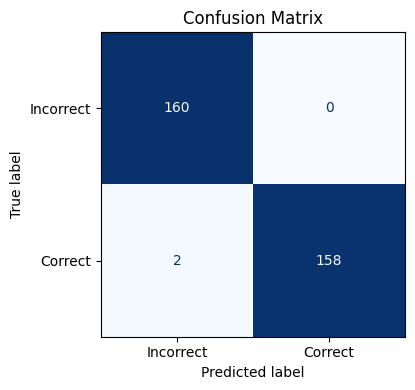

✅  Model ready.
════════════════════════════════════════════════════
  🎤  You should have read:
      اعتقد أن مواقع التواصل الإجتماعي جدا بناتية.
════════════════════════════════════════════════════

📤  Upload your recording (.wav or .m4a):


Saving Enregistrement (22).m4a to Enregistrement (22).m4a

📁  File     : Enregistrement (22).m4a
⏱️   Duration : 5.93 s

════════════════════════════════════════════════════
  ✅  CORRECT pronunciation  (94.4% confidence)
════════════════════════════════════════════════════

📋  Sentence : اعتقد أن مواقع التواصل الإجتماعي جدا بناتية.

  ✅  No pronunciation errors detected — great job!



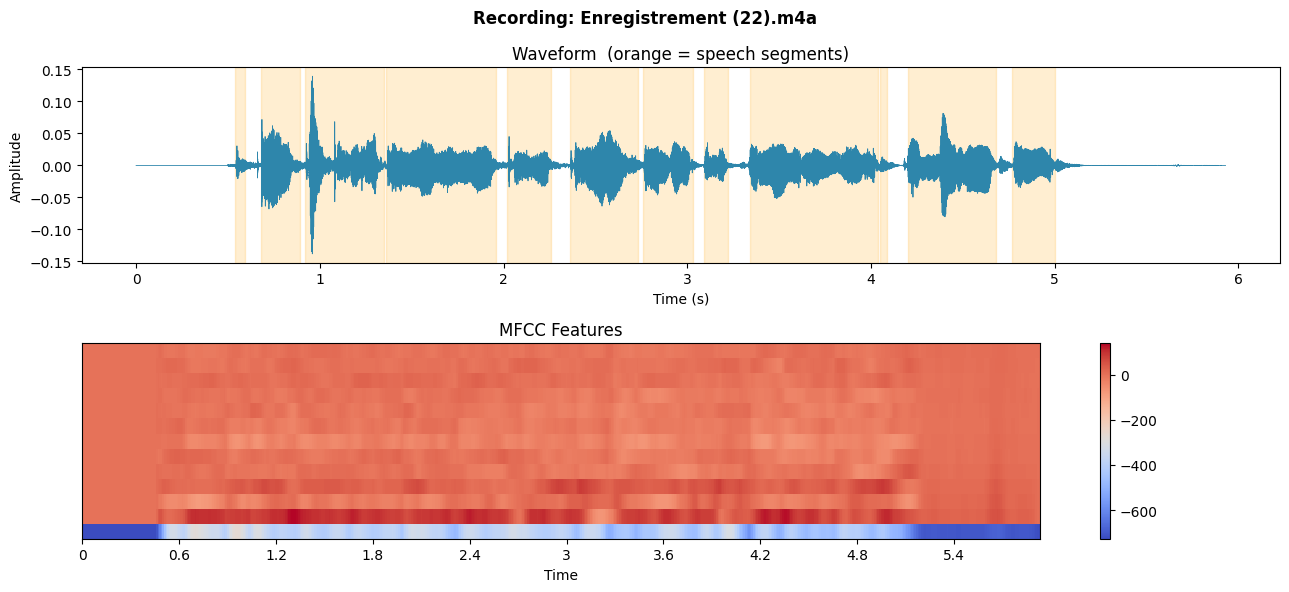

✅  Plot saved → recording_analysis.png


In [ ]:
# Linear Regression
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import re, warnings, time
from tqdm import tqdm
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
np.random.seed(int(time.time()) % (2**32))

SR        = 16_000
N_MFCC    = 13
N_TRAIN   = 800
FRAME_LEN = int(SR * 0.025)
HOP_LEN   = int(SR * 0.010)

GLOBAL_INCORRECT_THRESHOLD = 0.40

PHONEME_ERROR_THRESHOLD    = 0.15

print("✅  Ready.")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — Random Arabic sentence
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("📥  Fetching a random sentence …")

ds_text = load_dataset(
    "MohamedRashad/common-voice-18-arabic",
    split="train",
    streaming=True,
)

SKIP = np.random.randint(0, 5000)
pool = []
for i, sample in enumerate(ds_text):
    if i < SKIP:
        continue
    text = (sample.get("sentence") or "").strip()
    if text and re.search(r"[\u0600-\u06FF]", text) and len(text.split()) >= 2:
        pool.append(text)
    if len(pool) >= 200:
        break

TARGET_SENTENCE = pool[np.random.randint(len(pool))]

print("\n" + "═" * 52)
print("  🎤  READ THIS SENTENCE ALOUD:")
print("═" * 52)
print(f"\n      {TARGET_SENTENCE}\n")
print("═" * 52)
print("\n  Record yourself, save as .wav (or .m4a), then")
print("  run the remaining cells.\n")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — Feature extraction + augmentation
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def extract_features(audio: np.ndarray, sr: int = SR) -> np.ndarray | None:
    if audio is None or len(audio) < FRAME_LEN:
        return None
    audio = audio.astype(np.float32)
    peak = np.abs(audio).max()
    if peak > 0:
        audio /= peak
    try:
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC,
                                     n_fft=FRAME_LEN, hop_length=HOP_LEN)
        parts = []
        for mat in (
            mfcc,
            librosa.feature.delta(mfcc),
            librosa.feature.delta(mfcc, order=2),
            librosa.feature.rms(y=audio, frame_length=FRAME_LEN, hop_length=HOP_LEN),
            librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=HOP_LEN),
            librosa.feature.zero_crossing_rate(y=audio, frame_length=FRAME_LEN,
                                                hop_length=HOP_LEN),
        ):
            parts += [np.mean(mat, axis=1), np.std(mat, axis=1)]
        return np.concatenate(parts)
    except Exception:
        return None


def make_incorrect(audio: np.ndarray, sr: int = SR, seed: int = 0) -> np.ndarray:
    """
    FIX 3: subtler distortions — they now better mimic real mispronunciation
    rather than extreme pitch/speed changes that no human would make.
    """
    rng  = np.random.default_rng(seed)
    t    = seed % 6
    if t == 0:
        # Slight pitch up (1.5 steps) — vowel quality shift
        return librosa.effects.pitch_shift(audio, sr=sr, n_steps=1.5)
    elif t == 1:
        # Slight pitch down
        return librosa.effects.pitch_shift(audio, sr=sr, n_steps=-1.5)
    elif t == 2:
        # Mild speed-up (sounds rushed)
        return librosa.effects.time_stretch(audio, rate=1.15)
    elif t == 3:
        # Mild slow-down (sounds hesitant)
        return librosa.effects.time_stretch(audio, rate=0.87)
    elif t == 4:
        # Low-level noise (microphone / room noise)
        power = np.mean(audio ** 2) + 1e-9
        noise = rng.normal(0, np.sqrt(power / (10 ** (12 / 10))), len(audio)).astype(np.float32)
        return np.clip(audio + noise, -1.0, 1.0)
    else:
        # Formant-like smearing via short reverb
        ir_len = int(sr * 0.03)
        ir = np.exp(-np.linspace(0, 6, ir_len)).astype(np.float32)
        ir /= ir.sum()
        out = np.convolve(audio, ir, mode="full")[: len(audio)]
        return out.astype(np.float32)


print("✅  Feature helpers ready.")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — Train + calibrate Logistic Regression
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f"📥  Streaming {N_TRAIN} audio clips for training …\n")

ds_audio = load_dataset(
    "MohamedRashad/common-voice-18-arabic",
    split="train",
    streaming=True,
)

X_list, y_list = [], []
count = 0
for i, sample in enumerate(tqdm(ds_audio, total=N_TRAIN, desc="Building dataset")):
    if count >= N_TRAIN:
        break
    try:
        audio   = np.array(sample["audio"]["array"], dtype=np.float32)
        orig_sr = sample["audio"]["sampling_rate"]
        if orig_sr != SR:
            audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=SR)
        if len(audio) < SR * 0.3:
            continue
        f = extract_features(audio)
        if f is None:
            continue
        X_list.append(f); y_list.append(1)
        fb = extract_features(make_incorrect(audio, SR, seed=i))
        if fb is not None:
            X_list.append(fb); y_list.append(0)
        count += 1
    except Exception:
        continue

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)
print(f"\n✅  {sum(y==1)} correct  |  {sum(y==0)} incorrect")

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

base_model = LogisticRegression(C=2.0, max_iter=2000,
                                 solver="lbfgs", random_state=42)
model = CalibratedClassifierCV(base_model, method="isotonic", cv=5)
model.fit(X_tr_sc, y_tr)

y_pred = model.predict(X_te_sc)
print(f"\n📊  Test Accuracy : {accuracy_score(y_te, y_pred)*100:.2f}%")
print(classification_report(y_te, y_pred, target_names=["Incorrect", "Correct"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
                       display_labels=["Incorrect","Correct"]).plot(ax=ax, cmap="Blues",
                                                                    colorbar=False)
ax.set_title("Confusion Matrix"); plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150); plt.show()
print("✅  Model ready.")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — Arabic G2P
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ARABIC_G2P = {
    "ا":"aː","أ":"ʔa","إ":"ʔi","آ":"ʔaː","ء":"ʔ","ى":"aː","ة":"t",
    "و":"w","ي":"j","ب":"b","ت":"t","ث":"θ","ج":"dʒ","ح":"ħ","خ":"x",
    "د":"d","ذ":"ð","ر":"r","ز":"z","س":"s","ش":"ʃ","ص":"sˤ","ض":"dˤ",
    "ط":"tˤ","ظ":"ðˤ","ع":"ʕ","غ":"ɣ","ف":"f","ق":"q","ك":"k",
    "ل":"l","م":"m","ن":"n","ه":"h",
}
CONFUSABLE = {"q":"k","θ":"s","ð":"z","sˤ":"s","dˤ":"d",
              "tˤ":"t","ðˤ":"ð","ħ":"h","x":"k","ʕ":"ʔ","r":"l"}
EMPHATIC   = {"sˤ","dˤ","tˤ","ðˤ"}
GUTTURAL   = {"q","ħ","ʕ","x","ɣ"}
TIPS       = {
    "q":  "Uvular stop — produced deep in the throat, not like /k/",
    "ħ":  "Pharyngeal fricative — constrict the throat strongly",
    "ʕ":  "Voiced pharyngeal — voiced version of ħ",
    "sˤ": "Emphatic /s/ — back the tongue, round the lips slightly",
    "dˤ": "Emphatic /d/ — same backing as sˤ",
    "tˤ": "Emphatic /t/ — same backing as sˤ",
    "ðˤ": "Emphatic /ð/ — pharyngealised dental fricative",
    "θ":  "Dental fricative — tongue tip between teeth ('th' in 'think')",
    "ð":  "Voiced dental — tongue tip between teeth ('th' in 'this')",
    "x":  "Velar fricative — like 'ch' in German 'Bach'",
    "ʔ":  "Glottal stop — brief closure of vocal cords",
}

def text_to_phonemes(text: str):
    text = re.sub(r"[\u064B-\u065F\u0670]", "", text)
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text).strip()
    result = []
    for word in text.split():
        phs = [ARABIC_G2P[c] for c in word if c in ARABIC_G2P]
        if phs:
            result.append((word, phs))
    return result


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — Upload & Analyse
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from google.colab import files as colab_files

print("═" * 52)
print(f"  🎤  You should have read:\n      {TARGET_SENTENCE}")
print("═" * 52)
print("\n📤  Upload your recording (.wav or .m4a):")
uploaded = colab_files.upload()

for filename, raw in uploaded.items():
    with open(filename, "wb") as f:
        f.write(raw)

    audio, file_sr = librosa.load(filename, sr=None, mono=True)
    if file_sr != SR:
        audio = librosa.resample(audio, orig_sr=file_sr, target_sr=SR)

    print(f"\n📁  File     : {filename}")
    print(f"⏱️   Duration : {len(audio)/SR:.2f} s")

    feat_global = extract_features(audio)
    if feat_global is None:
        print("❌  Clip too short or silent."); continue

    feat_sc      = scaler.transform(feat_global.reshape(1, -1))
    global_probs = model.predict_proba(feat_sc)[0]   # [P(incorrect), P(correct)]
    prob_correct = float(global_probs[1])

    # ── FIX 1 applied: use threshold instead of argmax
    is_correct  = prob_correct >= GLOBAL_INCORRECT_THRESHOLD
    global_conf = prob_correct if is_correct else (1 - prob_correct)

    print("\n" + "═"*52)
    if is_correct:
        print(f"  ✅  CORRECT pronunciation  ({prob_correct*100:.1f}% confidence)")
    else:
        print(f"  ❌  INCORRECT pronunciation  ({prob_correct*100:.1f}% correct score)")
    print("═"*52)

    # ── Phoneme segmentation
    word_phonemes = text_to_phonemes(TARGET_SENTENCE)
    flat          = [(w, p) for w, phs in word_phonemes for p in phs]
    n_expected    = len(flat)

    eng    = librosa.feature.rms(y=audio, frame_length=FRAME_LEN, hop_length=HOP_LEN)[0]
    voiced = eng > eng.mean() * 0.4
    segs, in_s, s0 = [], False, 0
    for i, v in enumerate(voiced):
        if v and not in_s:
            s0, in_s = i, True
        elif not v and in_s:
            if i - s0 >= 4:
                segs.append((
                    librosa.frames_to_samples(s0, hop_length=HOP_LEN),
                    min(librosa.frames_to_samples(i, hop_length=HOP_LEN), len(audio))
                ))
            in_s = False
    if in_s:
        segs.append((librosa.frames_to_samples(s0, hop_length=HOP_LEN), len(audio)))

    n_segs = len(segs)

    def seg_idx_for(phoneme_i, n_ph, n_sg):
        if n_sg == 0: return -1
        return min(int(phoneme_i * n_sg / n_ph), n_sg - 1)

    # ── Per-phoneme scoring
    errors = []
    for i, (w, ph) in enumerate(flat):
        si = seg_idx_for(i, n_expected, n_segs)
        if si < 0:
            conf_ph = prob_correct
        else:
            s_, e_ = segs[si]
            seg = audio[s_:e_]
            if len(seg) < FRAME_LEN:
                seg = np.pad(seg, (0, FRAME_LEN - len(seg)))
            fseg = extract_features(seg)
            conf_ph = prob_correct if fseg is None else float(
                model.predict_proba(scaler.transform(fseg.reshape(1, -1)))[0][1])

        # Gate: only flag phonemes when global is also wrong,
        #       and only when confidence is very low
        if is_correct:
            etype, sub = None, None
        elif conf_ph < PHONEME_ERROR_THRESHOLD and ph in CONFUSABLE:
            etype, sub = "substitution", CONFUSABLE[ph]
        elif conf_ph < PHONEME_ERROR_THRESHOLD:
            etype, sub = "mispronunciation", "?"
        else:
            etype, sub = None, None

        if etype:
            errors.append({"word": w, "phoneme": ph, "phoneme_idx": i+1,
                           "type": etype, "sub": sub, "conf": conf_ph})

    # ── Display
    print(f"\n📋  Sentence : {TARGET_SENTENCE}\n")

    if not errors:
        print("  ✅  No pronunciation errors detected — great job!\n")
    else:
        print(f"  ⚠️  Found {len(errors)} error(s):\n")
        for j, e in enumerate(errors, 1):
            ph   = e["phoneme"]
            word = e["word"]
            tag  = " [emphatic]" if ph in EMPHATIC else (" [guttural]" if ph in GUTTURAL else "")
            detail = f"/{ph}/ sounds like /{e['sub']}/" if e["type"] == "substitution" else f"/{ph}/ needs work"
            print(f"  Error {j}: '{word}'  →  {detail}{tag}")
            if ph in TIPS:
                print(f"          💡 {TIPS[ph]}")
            print()

    hard_phonemes = {p for _, p in flat if p in GUTTURAL or p in EMPHATIC}
    tips_to_show  = {p for p in hard_phonemes if p in TIPS} - {e["phoneme"] for e in errors}
    if tips_to_show and not is_correct:
        print("  📌  Other difficult sounds in this sentence:")
        for ph in sorted(tips_to_show):
            print(f"      /{ph}/  →  {TIPS[ph]}")
        print()

    # ── Plot
    fig, axes = plt.subplots(2, 1, figsize=(13, 6))
    fig.suptitle(f"Recording: {filename}", fontsize=12, fontweight="bold")
    t = np.linspace(0, len(audio)/SR, len(audio))
    axes[0].plot(t, audio, color="#2E86AB", lw=0.6)
    for s_, e_ in segs:
        axes[0].axvspan(s_/SR, e_/SR, alpha=0.18, color="orange")
    axes[0].set_title("Waveform  (orange = speech segments)")
    axes[0].set_ylabel("Amplitude"); axes[0].set_xlabel("Time (s)")
    mfcc_mat = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC, hop_length=HOP_LEN)
    img = librosa.display.specshow(mfcc_mat, sr=SR, hop_length=HOP_LEN,
                                   x_axis="time", ax=axes[1])
    plt.colorbar(img, ax=axes[1])
    axes[1].set_title("MFCC Features")
    plt.tight_layout()
    plt.savefig("recording_analysis.png", dpi=150)
    plt.show()
    print("✅  Plot saved → recording_analysis.png")

# Implementation Support Vector Machine

In [ ]:
# ARABIC PHONETIC ERROR DETECTION SVM
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import re, warnings, time
from tqdm import tqdm
from datasets import load_dataset

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              ConfusionMatrixDisplay, confusion_matrix)

warnings.filterwarnings("ignore")
np.random.seed(int(time.time()) % (2**32))

SR        = 16_000
N_MFCC    = 13
N_TRAIN   = 800
FRAME_LEN = int(SR * 0.025)
HOP_LEN   = int(SR * 0.010)

GLOBAL_INCORRECT_THRESHOLD = 0.25

PHONEME_ERROR_THRESHOLD    = 0.10

SVM_KERNEL = "rbf"
SVM_C      = 5.0
SVM_GAMMA  = "scale"
PCA_DIM    = 50

print(f"✅  Ready.  SVM: kernel={SVM_KERNEL}, C={SVM_C}, gamma={SVM_GAMMA}, PCA={PCA_DIM}")
print(f"    Global threshold={GLOBAL_INCORRECT_THRESHOLD}  |  Phoneme threshold={PHONEME_ERROR_THRESHOLD}")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 3 — Random Arabic sentence
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print("📥  Fetching a random sentence …")

ds_text = load_dataset(
    "MohamedRashad/common-voice-18-arabic",
    split="train",
    streaming=True,
)

SKIP = np.random.randint(0, 5000)
pool = []
for i, sample in enumerate(ds_text):
    if i < SKIP:
        continue
    text = (sample.get("sentence") or "").strip()
    if text and re.search(r"[\u0600-\u06FF]", text) and len(text.split()) >= 2:
        pool.append(text)
    if len(pool) >= 200:
        break

TARGET_SENTENCE = pool[np.random.randint(len(pool))]

print("\n" + "=" * 52)
print("  READ THIS SENTENCE ALOUD:")
print("=" * 52)
print(f"\n      {TARGET_SENTENCE}\n")
print("=" * 52)
print("\n  Record yourself, save as .wav (or .m4a), then")
print("  run the remaining cells.\n")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 4 — Feature extraction + augmentation helpers
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def extract_features(audio: np.ndarray, sr: int = SR):
    if audio is None or len(audio) < FRAME_LEN:
        return None
    audio = audio.astype(np.float32)
    peak = np.abs(audio).max()
    if peak > 0:
        audio /= peak
    try:
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC,
                                     n_fft=FRAME_LEN, hop_length=HOP_LEN)
        parts = []
        for mat in (
            mfcc,
            librosa.feature.delta(mfcc),
            librosa.feature.delta(mfcc, order=2),
            librosa.feature.rms(y=audio, frame_length=FRAME_LEN, hop_length=HOP_LEN),
            librosa.feature.spectral_centroid(y=audio, sr=sr, hop_length=HOP_LEN),
            librosa.feature.zero_crossing_rate(y=audio, frame_length=FRAME_LEN,
                                                hop_length=HOP_LEN),
        ):
            parts += [np.mean(mat, axis=1), np.std(mat, axis=1)]
        return np.concatenate(parts)
    except Exception:
        return None


def make_incorrect(audio: np.ndarray, sr: int = SR, seed: int = 0) -> np.ndarray:
    """Subtle distortions that mimic real mispronunciation."""
    rng = np.random.default_rng(seed)
    t   = seed % 6
    if t == 0:
        return librosa.effects.pitch_shift(audio, sr=sr, n_steps=1.5)
    elif t == 1:
        return librosa.effects.pitch_shift(audio, sr=sr, n_steps=-1.5)
    elif t == 2:
        return librosa.effects.time_stretch(audio, rate=1.15)
    elif t == 3:
        return librosa.effects.time_stretch(audio, rate=0.87)
    elif t == 4:
        power = np.mean(audio ** 2) + 1e-9
        noise = rng.normal(0, np.sqrt(power / (10 ** (12 / 10))), len(audio)).astype(np.float32)
        return np.clip(audio + noise, -1.0, 1.0)
    else:
        ir_len = int(sr * 0.03)
        ir = np.exp(-np.linspace(0, 6, ir_len)).astype(np.float32)
        ir /= ir.sum()
        return np.convolve(audio, ir, mode="full")[: len(audio)].astype(np.float32)


def augment_for_mic(audio: np.ndarray, sr: int = SR, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    out = audio.astype(np.float32).copy()

    # 1. Background noise at ~25 dB SNR
    power = np.mean(out ** 2) + 1e-9
    noise = rng.normal(0, np.sqrt(power / (10 ** (25 / 10))), len(out)).astype(np.float32)
    out = np.clip(out + noise, -1.0, 1.0)

    # 2. Short room reverb (20 ms exponential IR)
    ir_len = int(sr * 0.020)
    ir = np.exp(-np.linspace(0, 5, ir_len)).astype(np.float32)
    ir /= ir.sum()
    out = np.convolve(out, ir, mode="full")[: len(out)].astype(np.float32)

    # 3. Codec band-limiting: downsample to 8 kHz then back to sr
    #    This smears MFCC coefficients the same way AAC compression does.
    if sr >= 8000:
        down = librosa.resample(out, orig_sr=sr, target_sr=8000)
        out  = librosa.resample(down, orig_sr=8000, target_sr=sr)
        if len(out) > len(audio):
            out = out[: len(audio)]
        elif len(out) < len(audio):
            out = np.pad(out, (0, len(audio) - len(out)))

    peak = np.abs(out).max()
    if peak > 0:
        out /= peak
    return out


print("✅  Feature helpers ready.")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 5 — Build dataset & train SVM
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print(f"📥  Streaming {N_TRAIN} audio clips for training ...\n")

ds_audio = load_dataset(
    "MohamedRashad/common-voice-18-arabic",
    split="train",
    streaming=True,
)

X_list, y_list = [], []
count = 0
for i, sample in enumerate(tqdm(ds_audio, total=N_TRAIN, desc="Building dataset")):
    if count >= N_TRAIN:
        break
    try:
        audio   = np.array(sample["audio"]["array"], dtype=np.float32)
        orig_sr = sample["audio"]["sampling_rate"]
        if orig_sr != SR:
            audio = librosa.resample(audio, orig_sr=orig_sr, target_sr=SR)
        if len(audio) < SR * 0.3:
            continue

        f = extract_features(audio)
        if f is None:
            continue
        X_list.append(f);  y_list.append(1)

        f_mic = extract_features(augment_for_mic(audio, SR, seed=i + 10_000))
        if f_mic is not None:
            X_list.append(f_mic);  y_list.append(1)

        # Mispronunciation-distorted sample (label=0)
        fb = extract_features(make_incorrect(audio, SR, seed=i))
        if fb is not None:
            X_list.append(fb);  y_list.append(0)

        count += 1
    except Exception:
        continue

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)
print(f"\n  {sum(y==1)} correct variants  |  {sum(y==0)} incorrect variants")

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

safe_pca = min(PCA_DIM, X_tr.shape[0] - 1, X_tr.shape[1])

model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=safe_pca, random_state=42)),
    ("svm",    SVC(
        kernel=SVM_KERNEL,
        C=SVM_C,
        gamma=SVM_GAMMA,
        probability=True,   # Platt scaling -> reliable predict_proba
        random_state=42,
        max_iter=-1,
    )),
])

print(f"\nTraining SVM (kernel={SVM_KERNEL}, C={SVM_C}) on {len(X_tr)} samples ...")
model.fit(X_tr, y_tr)

y_pred = model.predict(X_te)
print(f"\nTest Accuracy : {accuracy_score(y_te, y_pred)*100:.2f}%")
print(classification_report(y_te, y_pred,
                             target_names=["Incorrect", "Correct"],
                             zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_te, y_pred),
    display_labels=["Incorrect", "Correct"]
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix - SVM")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("SVM model ready.")


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 6 — Arabic G2P
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
ARABIC_G2P = {
    "a":"a:","a":"a","i":"i","u":"u",
    "a":"a:","a":"a","u":"u:","i":"i:",
    "b":"b","t":"t","th":"th","j":"dZ","H":"H","kh":"x",
    "d":"d","dh":"D","r":"r","z":"z","s":"s","sh":"S","S":"S`","D":"D`",
    "T":"T`","Z":"Z`","E":"E","gh":"G","f":"f","q":"q","k":"k",
    "l":"l","m":"m","n":"n","h":"h","w":"w","y":"j",
}

ARABIC_G2P = {
    "\u0627":"a\u02d0","\u0623":"\u0294a","\u0625":"\u0294i","\u0622":"\u0294a\u02d0",
    "\u0621":"\u0294","\u0649":"a\u02d0","\u0629":"t",
    "\u0648":"w","\u064a":"j","\u0628":"b","\u062a":"t","\u062b":"\u03b8",
    "\u062c":"d\u0292","\u062d":"\u0127","\u062e":"x",
    "\u062f":"d","\u0630":"\u00f0","\u0631":"r","\u0632":"z","\u0633":"s",
    "\u0634":"\u0283","\u0635":"s\u02e4","\u0636":"d\u02e4",
    "\u0637":"t\u02e4","\u0638":"\u00f0\u02e4","\u0639":"\u0295","\u063a":"\u0263",
    "\u0641":"f","\u0642":"q","\u0643":"k",
    "\u0644":"l","\u0645":"m","\u0646":"n","\u0647":"h",
}
CONFUSABLE = {"q":"k","\u03b8":"s","\u00f0":"z","s\u02e4":"s","d\u02e4":"d",
              "t\u02e4":"t","\u00f0\u02e4":"\u00f0","\u0127":"h","x":"k",
              "\u0295":"\u0294","r":"l"}
EMPHATIC   = {"s\u02e4","d\u02e4","t\u02e4","\u00f0\u02e4"}
GUTTURAL   = {"q","\u0127","\u0295","x","\u0263"}
TIPS = {
    "q":  "Uvular stop - produced deep in the throat, not like /k/",
    "\u0127":  "Pharyngeal fricative - constrict the throat strongly",
    "\u0295":  "Voiced pharyngeal - voiced version of H",
    "s\u02e4": "Emphatic /s/ - back the tongue, round the lips slightly",
    "d\u02e4": "Emphatic /d/ - same backing as emphatic s",
    "t\u02e4": "Emphatic /t/ - same backing as emphatic s",
    "\u00f0\u02e4": "Emphatic /dh/ - pharyngealised dental fricative",
    "\u03b8":  "Dental fricative - tongue tip between teeth ('th' in 'think')",
    "\u00f0":  "Voiced dental - tongue tip between teeth ('th' in 'this')",
    "x":  "Velar fricative - like 'ch' in German 'Bach'",
    "\u0294":  "Glottal stop - brief closure of vocal cords",
}

def text_to_phonemes(text: str):
    text = re.sub(r"[\u064B-\u065F\u0670]", "", text)
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text).strip()
    result = []
    for word in text.split():
        phs = [ARABIC_G2P[c] for c in word if c in ARABIC_G2P]
        if phs:
            result.append((word, phs))
    return result


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CELL 7 — Upload & Analyse
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
from google.colab import files as colab_files

print("=" * 52)
print(f"  You should have read:\n      {TARGET_SENTENCE}")
print("=" * 52)
print("\nUpload your recording (.wav or .m4a):")
uploaded = colab_files.upload()

for filename, raw in uploaded.items():
    with open(filename, "wb") as f:
        f.write(raw)

    audio, file_sr = librosa.load(filename, sr=None, mono=True)
    if file_sr != SR:
        audio = librosa.resample(audio, orig_sr=file_sr, target_sr=SR)

    print(f"\nFile     : {filename}")
    print(f"Duration : {len(audio)/SR:.2f} s")

    feat_global = extract_features(audio)
    if feat_global is None:
        print("ERROR: Clip too short or silent.")
        continue

    # Global SVM verdict
    global_probs = model.predict_proba(feat_global.reshape(1, -1))[0]
    prob_correct = float(global_probs[1])   # P(correct)

    is_correct = prob_correct >= GLOBAL_INCORRECT_THRESHOLD

    # FIX D: confidence band so users understand borderline results
    if prob_correct >= 0.60:
        band = "clearly correct"
    elif prob_correct >= GLOBAL_INCORRECT_THRESHOLD:
        band = "likely correct (borderline)"
    elif prob_correct >= 0.12:
        band = "likely incorrect (borderline)"
    else:
        band = "clearly incorrect"

    print("\n" + "=" * 52)
    print(f"  P(correct) = {prob_correct*100:.1f}%  ->  {band}")
    verdict = "CORRECT" if is_correct else "INCORRECT"
    print(f"  Verdict: {verdict} pronunciation")
    print("=" * 52)

    # Phoneme segmentation (energy-based)
    word_phonemes = text_to_phonemes(TARGET_SENTENCE)
    flat          = [(w, p) for w, phs in word_phonemes for p in phs]
    n_expected    = len(flat)

    eng    = librosa.feature.rms(y=audio, frame_length=FRAME_LEN, hop_length=HOP_LEN)[0]
    voiced = eng > eng.mean() * 0.4
    segs, in_s, s0 = [], False, 0
    for i, v in enumerate(voiced):
        if v and not in_s:
            s0, in_s = i, True
        elif not v and in_s:
            if i - s0 >= 4:
                segs.append((
                    librosa.frames_to_samples(s0, hop_length=HOP_LEN),
                    min(librosa.frames_to_samples(i, hop_length=HOP_LEN), len(audio))
                ))
            in_s = False
    if in_s:
        segs.append((librosa.frames_to_samples(s0, hop_length=HOP_LEN), len(audio)))

    n_segs = len(segs)

    def seg_idx_for(phoneme_i, n_ph, n_sg):
        if n_sg == 0:
            return -1
        return min(int(phoneme_i * n_sg / n_ph), n_sg - 1)

    # Per-phoneme scoring
    errors = []
    for i, (w, ph) in enumerate(flat):
        si = seg_idx_for(i, n_expected, n_segs)
        if si < 0:
            conf_ph = prob_correct
        else:
            s_, e_ = segs[si]
            seg = audio[s_:e_]
            if len(seg) < FRAME_LEN:
                seg = np.pad(seg, (0, FRAME_LEN - len(seg)))
            fseg = extract_features(seg)
            conf_ph = (prob_correct if fseg is None
                       else float(model.predict_proba(fseg.reshape(1, -1))[0][1]))

        if is_correct:
            etype, sub = None, None
        elif conf_ph < PHONEME_ERROR_THRESHOLD and ph in CONFUSABLE:
            etype, sub = "substitution", CONFUSABLE[ph]
        elif conf_ph < PHONEME_ERROR_THRESHOLD:
            etype, sub = "mispronunciation", "?"
        else:
            etype, sub = None, None

        if etype:
            errors.append({"word": w, "phoneme": ph, "phoneme_idx": i + 1,
                           "type": etype, "sub": sub, "conf": conf_ph})

    print(f"\nSentence : {TARGET_SENTENCE}\n")

    if not errors:
        print("  No pronunciation errors detected - great job!\n")
    else:
        print(f"  Found {len(errors)} error(s):\n")
        for j, e in enumerate(errors, 1):
            ph   = e["phoneme"]
            word = e["word"]
            tag  = (" [emphatic]" if ph in EMPHATIC
                    else " [guttural]" if ph in GUTTURAL else "")
            detail = (f"/{ph}/ sounds like /{e['sub']}/"
                      if e["type"] == "substitution"
                      else f"/{ph}/ needs work")
            print(f"  Error {j}: '{word}'  ->  {detail}{tag}")
            if ph in TIPS:
                print(f"          Tip: {TIPS[ph]}")
            print()

    hard_phonemes = {p for _, p in flat if p in GUTTURAL or p in EMPHATIC}
    tips_to_show  = {p for p in hard_phonemes if p in TIPS} - {e["phoneme"] for e in errors}
    if tips_to_show and not is_correct:
        print("  Other difficult sounds in this sentence:")
        for ph in sorted(tips_to_show):
            print(f"      /{ph}/  ->  {TIPS[ph]}")
        print()

    # Plot waveform + MFCC
    fig, axes = plt.subplots(2, 1, figsize=(13, 6))
    fig.suptitle(
        f"{filename}  |  SVM: {band}  (P(correct)={prob_correct*100:.1f}%)",
        fontsize=11, fontweight="bold"
    )

    t = np.linspace(0, len(audio) / SR, len(audio))
    axes[0].plot(t, audio, color="#2E86AB", lw=0.6)
    for s_, e_ in segs:
        axes[0].axvspan(s_ / SR, e_ / SR, alpha=0.18, color="orange")
    axes[0].set_title("Waveform  (orange = speech segments)")
    axes[0].set_ylabel("Amplitude")
    axes[0].set_xlabel("Time (s)")

    mfcc_mat = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=N_MFCC, hop_length=HOP_LEN)
    img = librosa.display.specshow(mfcc_mat, sr=SR, hop_length=HOP_LEN,
                                   x_axis="time", ax=axes[1])
    plt.colorbar(img, ax=axes[1])
    axes[1].set_title("MFCC Features")

    plt.tight_layout()
    plt.savefig("recording_analysis.png", dpi=150)
    plt.show()
    print("Plot saved -> recording_analysis.png")